# Application to real data

This notebook applies the discussed methods in real data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from cmdstanpy import cmdstan_path, CmdStanModel, set_cmdstan_path, install_cmdstan

import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import arviz as az
import scienceplots
plt.style.use('science')

import sys
import os
sys.path.append('../scripts/python')
from tqdm.auto import tqdm

from parameter_estimation import BivariateBeta
from beta_loo import build_beta_loglik_cache, beta_bayes_loo_from_model_fit

Some pre sets:

In [3]:
folder = '../data/covid_tests_data/'
filter_func = lambda i: lambda x: float(re.findall('[0-9].[0-9][0-9]', x.replace(',', '.'))[i])

stanfile = os.path.join('..', 'scripts', 'stan', 'bivariate-beta-model-lognormal.stan')
model_lognormal = CmdStanModel(stan_file=stanfile, cpp_options={'STAN_THREADS': True})

stanfile = os.path.join('..', 'scripts', 'stan', 'bivariate-beta-model-gamma.stan')
model_gamma = CmdStanModel(stan_file=stanfile, cpp_options={'STAN_THREADS': True})

In [4]:
stanfile = os.path.join('..', 'scripts', 'stan', 'logit-bivariate-model.stan')
model_logit = CmdStanModel(stan_file=stanfile, cpp_options={'STAN_THREADS': True})

# Accuracy of diagnostic tests registered by ANVISA for COVID-19

A documentary investigation was carried out utilizing the information provided by manufacturers during their registration with Anvisa. 
The diagnostic tests recorded with Anvisa up to June 23, 2020, during the data collection period, were scrutinized through the use of the following link: [https://consultas.anvisa.gov.br/#/saude/q/?nomeTecnico=coronav%C3%ADrus](https://consultas.anvisa.gov.br/#/saude/q/?nomeTecnico=coronav%C3%ADrus).

The data that was registered with Anvisa during the time of registration was retrieved from the Agency's website, specifically from the General Management of Health Product Technology (GGTPS) for in vitro diagnosis. 
To present the data in a structured format, a standard table created by the authors was employed, gathering essential information such as: i) company/importer; ii) manufacturer/country; iii) sample; iv) whether it was classified as a quick test v) Anvisa registration number; vi) sensitivity/specificity data presented by the manufacturer. 
The information provided by the manufacturers during their registration with Anvisa was then used to generate graphs displaying the sensitivity and specificity of the diagnostic tests.

The data provided by the manufacturers were plotted in the figures presented to illustrate the IgG and/or IgM sensitivity and specificity of the tests:

a) immunochromatographic with blood sample (whole blood, venous whole blood, whole blood via digital puncture or dried blood), human serum or plasma;

b) immunochromatographic with secretion nasopharyngeal swab and oropharyngeal swab;

c) immunoassay with blood sample (whole blood, venous whole blood, whole blood via finger prick or dried blood), human serum or plasma;

d) immunoassay with nasopharyngeal swab and oropharyngeal swab secretion sample;

e) qualitative or semi-qualitative detection with blood sample

In [85]:
tables = [pd.read_csv(folder+'raw/table_a.csv'),
          pd.read_csv(folder+'raw/table_b.csv'),
          pd.read_csv(folder+'raw/table_c.csv'),
          pd.read_csv(folder+'raw/table_d.csv'),
          pd.read_csv(folder+'raw/table_e.csv'),
          pd.read_csv(folder+'raw/table_pcr_a.csv'),
          pd.read_csv(folder+'raw/table_pcr_b.csv'),
          pd.read_csv(folder+'raw/table_pcr_c.csv'),
         ]

letters = ['a', 'b', 'c', 'd', 'e', 'a_pcr', 'b_pcr', 'c_pcr']
for i in range(8):

    tables[i]['sensitivity']          = tables[i]['Sensitivity [95% CI]'].apply(filter_func(0))
    tables[i]['sensitivity_ci_lower'] = tables[i]['Sensitivity [95% CI]'].apply(filter_func(1))
    tables[i]['sensitivity_ci_upper'] = tables[i]['Sensitivity [95% CI]'].apply(filter_func(2))
    tables[i]['specificity']          = tables[i]['Specificity [95% CI]'].apply(filter_func(0))
    tables[i]['specificity_ci_lower'] = tables[i]['Specificity [95% CI]'].apply(filter_func(1))
    tables[i]['specificity_ci_upper'] = tables[i]['Specificity [95% CI]'].apply(filter_func(2))
    tables[i]['type']                 = letters[i]
    
    del tables[i]['Sensitivity [95% CI]']
    del tables[i]['Specificity [95% CI]']
    
df = pd.concat(tables)

In [86]:
df

,Study,TP,FP,FN,TN,sensitivity,sensitivity_ci_lower,sensitivity_ci_upper,specificity,specificity_ci_lower,specificity_ci_upper,type
0,10071770900,312,1,49,234,0.86,0.82,0.90,1.00,0.98,1.00,a
1,10071770901,46,3,2,47,0.96,0.86,0.99,0.94,0.83,0.99,a
2,10210410105,90,3,3,124,0.97,0.91,0.99,0.98,0.93,1.00,a
3,10310030208,171,12,12,514,0.93,0.89,0.97,0.98,0.96,0.99,a
4,10342880015,23,2,1,49,0.96,0.79,1.00,0.96,0.87,1.00,a
...,...,...,...,...,...,...,...,...,...,...,...,...
11,80867150018,209,10,0,370,1.00,0.98,1.00,0.97,0.95,0.99,a_pcr
12,80954880134,3,0,0,98,1.00,0.29,1.00,1.00,0.96,1.00,a_pcr
0,10009010357,60,0,0,60,1.00,0.94,1.00,1.00,0.94,1.00,b_pcr
1,10223400001,10,0,0,14,1.00,0.69,1.00,1.00,0.77,1.00,b_pcr


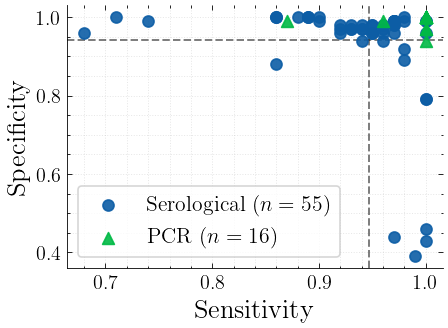

In [87]:
mask_pcr = df['type'].str.contains('pcr', case=False, na=False)
mask_ser = ~mask_pcr

m1 = df['sensitivity'].mean()
m2 = df['specificity'].mean()

plt.figure(figsize=(4,3), dpi=120)

# mean reference lines
plt.axvline(m1, linestyle='--', linewidth=1.2, color='black', alpha=0.5, zorder=2)
plt.axhline(m2, linestyle='--', linewidth=1.2, color='black', alpha=0.5, zorder=2)

# serological/immunoassay
plt.scatter(df.loc[mask_ser, 'sensitivity'],
            df.loc[mask_ser, 'specificity'],
            marker='o', s=44, alpha=0.9,
            label=rf"Serological ($n={mask_ser.sum()}$)", zorder=3)

# PCR/molecular
plt.scatter(df.loc[mask_pcr, 'sensitivity'],
            df.loc[mask_pcr, 'specificity'],
            marker='^', s=50, alpha=0.9,
            label=rf"PCR ($n={mask_pcr.sum()}$)", zorder=3)

plt.xlabel('Sensitivity', fontsize=16); plt.ylabel('Specificity', fontsize=16)
#plt.title('Sensitivity vs Specificity (Anvisa registrations)')
plt.grid(True, which='both', linestyle=':', linewidth=0.6, alpha=0.3)
plt.legend(loc='lower left', frameon=True, fontsize=13)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()

plt.savefig('../figures/anvisa_scatter.pdf', bbox_inches='tight')
plt.show()

In [88]:
df.describe()

,Study,TP,FP,FN,TN,sensitivity,sensitivity_ci_lower,sensitivity_ci_upper,specificity,specificity_ci_lower,specificity_ci_upper
count,7.100000e+01,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000
mean,5.591396e+10,115.394366,13.971831,7.183099,191.676056,0.946901,0.835070,0.976479,0.942958,0.881127,0.962676
std,3.390722e+10,97.261427,45.681810,11.856656,212.390192,0.065500,0.174076,0.037037,0.132432,0.154064,0.113187
min,1.000901e+10,2.000000,0.000000,0.000000,5.000000,0.680000,0.160000,0.820000,0.390000,0.320000,0.440000
25%,1.034136e+10,49.000000,0.500000,0.000000,60.000000,0.930000,0.820000,0.970000,0.960000,0.890000,0.990000
50%,8.025802e+10,92.000000,2.000000,3.000000,124.000000,0.970000,0.890000,0.990000,0.980000,0.930000,1.000000
75%,8.086715e+10,169.000000,9.000000,7.500000,241.000000,1.000000,0.925000,1.000000,1.000000,0.960000,1.000000
max,8.198451e+10,422.000000,297.000000,49.000000,1364.000000,1.000000,0.980000,1.000000,1.000000,0.990000,1.000000


In [89]:
distribution = BivariateBeta()

CASEB_EPSILON_CONFIGS = [
    ('eps_1e-4', 1e-4, r'$U(10^{-6},\,10^{-4})$'),
    ('eps_5e-4', 5e-4, r'$U(10^{-6},\,5 \times 10^{-4})$'),
    ('eps_1e-3', 1e-3, r'$U(10^{-6},\,10^{-3})$'),
]
CASEB_DEFAULT_KEY = 'eps_5e-4'
CASEB_DEFAULT_LABEL = next(label for key, _, label in CASEB_EPSILON_CONFIGS if key == CASEB_DEFAULT_KEY)

def build_caseB_dataset(df, eps_max, seed):
    x = df.sensitivity.values.copy()
    y = df.specificity.values.copy()
    rng = np.random.default_rng(seed=seed)
    x[x == 1] -= rng.uniform(1e-6, eps_max, size=(x == 1).sum())
    y[y == 1] -= rng.uniform(1e-6, eps_max, size=(y == 1).sum())
    return x, y

caseB_variants = {}
caseB_basic_rows = []
for offset, (key, eps_max, label) in enumerate(CASEB_EPSILON_CONFIGS):
    x_i, y_i = build_caseB_dataset(df, eps_max=eps_max, seed=13 + offset)
    m1_i = np.mean(x_i)
    m2_i = np.mean(y_i)
    v1_i = np.var(x_i, ddof=0)
    v2_i = np.var(y_i, ddof=0)
    rho_i = np.corrcoef(x_i, y_i)[0, 1]
    caseB_variants[key] = {
        'label': label,
        'eps_max': eps_max,
        'x': x_i,
        'y': y_i,
        'moments': np.array([m1_i, m2_i, v1_i, v2_i, rho_i]),
    }
    caseB_basic_rows.append({
        'dataset': label,
        'm1': m1_i,
        'm2': m2_i,
        'v1': v1_i,
        'v2': v2_i,
        'rho': rho_i,
        'n_x_eq_1': int((df.sensitivity.values == 1).sum()),
        'n_y_eq_1': int((df.specificity.values == 1).sum()),
    })

caseB_basic_df = pd.DataFrame(caseB_basic_rows)
display(caseB_basic_df.round(6))

x = caseB_variants[CASEB_DEFAULT_KEY]['x']
y = caseB_variants[CASEB_DEFAULT_KEY]['y']
m1, m2, v1, v2, rho = caseB_variants[CASEB_DEFAULT_KEY]['moments']
moments = caseB_variants[CASEB_DEFAULT_KEY]['moments'].tolist()
moments

,dataset,m1,m2,v1,v2,rho,n_x_eq_1,n_y_eq_1
0,"$U(10^{-6},\,10^{-4})$",0.946885,0.942941,0.004228,0.017289,-0.186976,21,21
1,"$U(10^{-6},\,5 \times 10^{-4})$",0.946816,0.942878,0.004221,0.017282,-0.186693,21,21
2,"$U(10^{-6},\,10^{-3})$",0.946738,0.942825,0.004213,0.017276,-0.187415,21,21


[0.9468155571718605,
 0.9428779585185375,
 0.0042207392751940015,
 0.01728217221691738,
 -0.18669270742573887]

In [90]:
caseB_feasibility_rows = []
for key, dataset in caseB_variants.items():
    m1_i, m2_i, v1_i, v2_i, _ = dataset['moments']
    caseB_feasibility_rows.append({
        'dataset': dataset['label'],
        'm1(1-m1)/v1 - m2(1-m2)/v2': m1_i * (1 - m1_i) / v1_i - m2_i * (1 - m2_i) / v2_i,
    })

caseB_feasibility_df = pd.DataFrame(caseB_feasibility_rows)
display(caseB_feasibility_df.round(6))

,dataset,m1(1-m1)/v1 - m2(1-m2)/v2
0,"$U(10^{-6},\,10^{-4})$",8.783103
1,"$U(10^{-6},\,5 \times 10^{-4})$",8.814123
2,"$U(10^{-6},\,10^{-3})$",8.849785


Estimating through the method of moments:

In [91]:
caseB_alpha_hat1 = {}
caseB_alpha_hat1_rows = []
for key, dataset in caseB_variants.items():
    alpha_hat = distribution.method_moments_estimator_1(dataset['x'], dataset['y'])
    implied = BivariateBeta(alpha_hat).moments()
    caseB_alpha_hat1[key] = alpha_hat
    caseB_alpha_hat1_rows.append({
        'dataset': dataset['label'],
        'alpha_1': alpha_hat[0],
        'alpha_2': alpha_hat[1],
        'alpha_3': alpha_hat[2],
        'alpha_4': alpha_hat[3],
        'm1': implied[0],
        'm2': implied[1],
        'v1': implied[2],
        'v2': implied[3],
        'rho': implied[4],
    })

caseB_alpha_hat1_df = pd.DataFrame(caseB_alpha_hat1_rows)
display(caseB_alpha_hat1_df.round(6))

alpha_hat1 = caseB_alpha_hat1[CASEB_DEFAULT_KEY]
BivariateBeta(alpha_hat1).moments()

,dataset,alpha_1,alpha_2,alpha_3,alpha_4,m1,m2,v1,v2,rho
0,"$U(10^{-6},\,10^{-4})$",9.694674,0.621656,0.578686,0.0,0.946885,0.942941,0.004228,0.004523,-0.058261
1,"$U(10^{-6},\,5 \times 10^{-4})$",9.724864,0.624377,0.581337,0.0,0.946816,0.942878,0.004221,0.004514,-0.058336
2,"$U(10^{-6},\,10^{-3})$",9.758534,0.627210,0.584283,0.0,0.946738,0.942825,0.004213,0.004503,-0.058409


array([ 0.94681556,  0.94287796,  0.00422074,  0.00451438, -0.05833561])

In [92]:
caseB_alpha_hat4 = {}
caseB_alpha_hat4_rows = []
for key, dataset in caseB_variants.items():
    alpha_hat = distribution.method_moments_estimator_4(dataset['x'], dataset['y'])
    implied = BivariateBeta(alpha_hat).moments()
    caseB_alpha_hat4[key] = alpha_hat
    caseB_alpha_hat4_rows.append({
        'dataset': dataset['label'],
        'alpha_1': alpha_hat[0],
        'alpha_2': alpha_hat[1],
        'alpha_3': alpha_hat[2],
        'alpha_4': alpha_hat[3],
        'm1': implied[0],
        'm2': implied[1],
        'v1': implied[2],
        'v2': implied[3],
        'rho': implied[4],
    })

caseB_alpha_hat4_df = pd.DataFrame(caseB_alpha_hat4_rows)
display(caseB_alpha_hat4_df.round(6))

alpha_hat4 = caseB_alpha_hat4[CASEB_DEFAULT_KEY]
BivariateBeta(alpha_hat4).moments()

,dataset,alpha_1,alpha_2,alpha_3,alpha_4,m1,m2,v1,v2,rho
0,"$U(10^{-6},\,10^{-4})$",5.880880,0.759294,0.732227,0.0,0.900680,0.897009,0.010685,0.011034,-0.112521
1,"$U(10^{-6},\,5 \times 10^{-4})$",5.882547,0.758942,0.731905,0.0,0.900737,0.897070,0.010678,0.011027,-0.112448
2,"$U(10^{-6},\,10^{-3})$",5.898607,0.763752,0.736780,0.0,0.900424,0.896778,0.010675,0.011021,-0.112823


array([ 0.90073703,  0.89707025,  0.01067785,  0.01102722, -0.11244803])

Frequentist diagnostics

In [93]:
caseB_marginal_diag_rows = []
for key, dataset in caseB_variants.items():
    stat, pvalue = distribution.marginal_diagnostic(dataset['x'], dataset['y'])
    caseB_marginal_diag_rows.append({
        'dataset': dataset['label'],
        'statistic': stat,
        'pvalue': pvalue,
    })

caseB_marginal_diag_df = pd.DataFrame(caseB_marginal_diag_rows)
display(caseB_marginal_diag_df.round(6))

,dataset,statistic,pvalue
0,"$U(10^{-6},\,10^{-4})$",2.144615,0.031984
1,"$U(10^{-6},\,5 \times 10^{-4})$",2.144292,0.032009
2,"$U(10^{-6},\,10^{-3})$",2.145668,0.031899


Since $p$-value $< 0.05$, it indicates strong evidence against the null hypothesis that the data comes from the bivariate beta distribution and the marginal distributions do not obey the necessary relation.

In [94]:
caseB_positive_diag_rows = []
for key, dataset in caseB_variants.items():
    caseB_positive_diag_rows.append({
        'dataset': dataset['label'],
        'positive_diagnostic': distribution.positive_diagnostic_diagnostic(dataset['x'], dataset['y']),
    })

caseB_positive_diag_df = pd.DataFrame(caseB_positive_diag_rows)
display(caseB_positive_diag_df.round(6))

,dataset,positive_diagnostic
0,"$U(10^{-6},\,10^{-4})$",-0.006696
1,"$U(10^{-6},\,5 \times 10^{-4})$",-0.006685
2,"$U(10^{-6},\,10^{-3})$",-0.006726


In [95]:
caseB_rho_bounds_rows = []
for key, dataset in caseB_variants.items():
    m1_i, m2_i, _, _, _ = dataset['moments']
    lower = -(min(m1_i * m2_i, (1 - m1_i) * (1 - m2_i))) / np.sqrt(m1_i * m2_i * (1 - m1_i) * (1 - m2_i))
    upper = (min(m1_i, m2_i) - m1_i * m2_i) / np.sqrt(m1_i * m2_i * (1 - m1_i) * (1 - m2_i))
    caseB_rho_bounds_rows.append({
        'dataset': dataset['label'],
        'rho_lower_bound': lower,
        'rho_upper_bound': upper,
    })

caseB_rho_bounds_df = pd.DataFrame(caseB_rho_bounds_rows)
display(caseB_rho_bounds_df.round(6))

,dataset,rho_lower_bound,rho_upper_bound
0,"$U(10^{-6},\,10^{-4})$",-0.058261,0.962809
1,"$U(10^{-6},\,5 \times 10^{-4})$",-0.058336,0.962910
2,"$U(10^{-6},\,10^{-3})$",-0.058409,0.963176


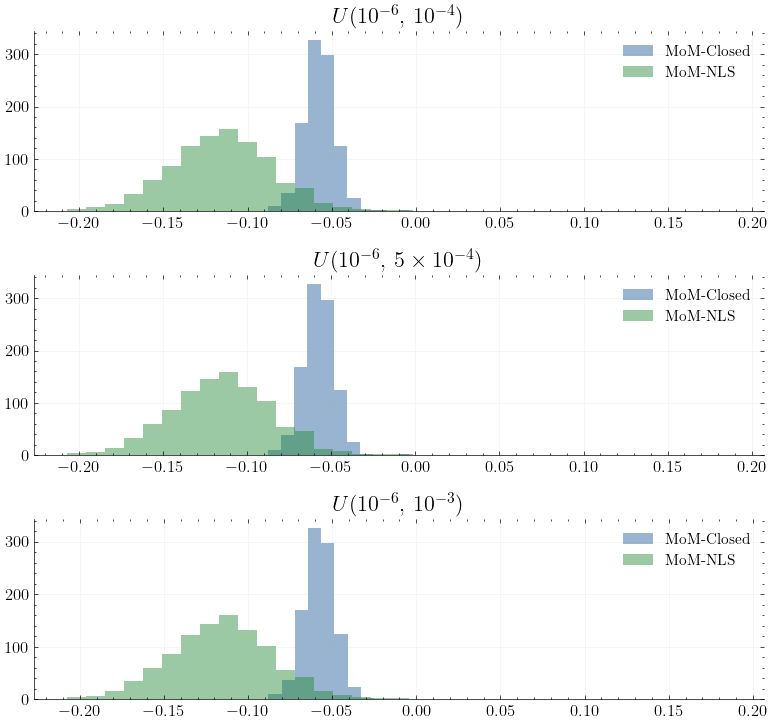

,dataset,mom_closed_rho_mean,mom_closed_rho_q025,mom_closed_rho_q975,mom_nls_rho_mean,mom_nls_rho_q025,mom_nls_rho_q975
0,"$U(10^{-6},\,10^{-4})$",-0.056824,-0.075757,-0.039113,-0.114627,-0.173683,-0.054942
1,"$U(10^{-6},\,5 \times 10^{-4})$",-0.056903,-0.075817,-0.039188,-0.114532,-0.173756,-0.055064
2,"$U(10^{-6},\,10^{-3})$",-0.056978,-0.075872,-0.039262,-0.114906,-0.174243,-0.055272


In [96]:
caseB_bootstrap_samples_1 = {}
caseB_bootstrap_samples_4 = {}
bootstrap_summary_rows = []

fig, axes = plt.subplots(len(caseB_variants), 1, figsize=(8, 2.5 * len(caseB_variants)), squeeze=False)
axes = axes.ravel()

for ax, (key, dataset) in zip(axes, caseB_variants.items()):
    bs1 = distribution.bootstrap_method(dataset['x'], dataset['y'], B=1000, method=distribution.method_moments_estimator_1)
    bs4 = distribution.bootstrap_method(dataset['x'], dataset['y'], B=1000, method=distribution.method_moments_estimator_4)
    caseB_bootstrap_samples_1[key] = bs1
    caseB_bootstrap_samples_4[key] = bs4

    rho1 = np.array([BivariateBeta(alpha).moments()[-1] for alpha in bs1.T])
    rho4 = np.array([BivariateBeta(alpha).moments()[-1] for alpha in bs4.T])

    bootstrap_summary_rows.append({
        'dataset': dataset['label'],
        'mom_closed_rho_mean': rho1.mean(),
        'mom_closed_rho_q025': np.quantile(rho1, 0.025),
        'mom_closed_rho_q975': np.quantile(rho1, 0.975),
        'mom_nls_rho_mean': rho4.mean(),
        'mom_nls_rho_q025': np.quantile(rho4, 0.025),
        'mom_nls_rho_q975': np.quantile(rho4, 0.975),
    })

    ax.hist(rho1, bins=35, alpha=0.55, label='MoM-Closed', color='#4477AA')
    ax.hist(rho4, bins=35, alpha=0.45, label='MoM-NLS', color='#228833')
    ax.set_title(dataset['label'])
    ax.legend()

plt.tight_layout()
plt.show()

caseB_bootstrap_summary_df = pd.DataFrame(bootstrap_summary_rows)
display(caseB_bootstrap_summary_df.round(6))

bootstrap_samples_1 = caseB_bootstrap_samples_1[CASEB_DEFAULT_KEY]
bootstrap_samples_4 = caseB_bootstrap_samples_4[CASEB_DEFAULT_KEY]

In [97]:
a = np.array([1, 1, 1, 1])

caseB_model_fits = {}
for offset, (key, dataset) in enumerate(caseB_variants.items()):
    data = {'n': dataset['x'].shape[0], 'a': a, 'xy': np.column_stack([dataset['x'], dataset['y']]), 's_mu': 4, 's_sd': 1, 'kappa': 4, 'lambda': 1}
    caseB_model_fits[key] = model_lognormal.sample(
        data=data,
        iter_warmup=2000,
        iter_sampling=2000,
        chains=4,
        adapt_delta=0.99,
        seed=372189 + offset,
    )

model_fit = caseB_model_fits[CASEB_DEFAULT_KEY]

16:41:48 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

16:43:29 - cmdstanpy - INFO - CmdStan done processing.


In [98]:
caseB_idata = {}
caseB_alpha_summary = {}
alpha_summary_rows = []

for key, model_fit_i in caseB_model_fits.items():
    idata_i = az.from_cmdstanpy(posterior=model_fit_i)
    summary_i = az.summary(idata_i, hdi_prob=0.95, stat_funcs={"median": np.median}).loc[[f'alpha[{i}]' for i in range(4)]]
    caseB_idata[key] = idata_i
    caseB_alpha_summary[key] = summary_i
    block = summary_i[['mean', 'median', 'hdi_2.5%', 'hdi_97.5%']].copy()
    block.insert(0, 'parameter', block.index)
    block.insert(0, 'dataset', caseB_variants[key]['label'])
    alpha_summary_rows.append(block.reset_index(drop=True))

caseB_alpha_summary_df = pd.concat(alpha_summary_rows, ignore_index=True)
display(caseB_alpha_summary_df.round(4))

idata = caseB_idata[CASEB_DEFAULT_KEY]
df = caseB_alpha_summary[CASEB_DEFAULT_KEY]
df

,dataset,parameter,mean,median,hdi_2.5%,hdi_97.5%
0,"$U(10^{-6},\,10^{-4})$",alpha[0],3.843,3.806,2.534,5.205
1,"$U(10^{-6},\,10^{-4})$",alpha[1],0.145,0.144,0.103,0.187
2,"$U(10^{-6},\,10^{-4})$",alpha[2],0.201,0.199,0.151,0.257
3,"$U(10^{-6},\,10^{-4})$",alpha[3],0.130,0.129,0.093,0.168
4,"$U(10^{-6},\,5 \times 10^{-4})$",alpha[0],4.402,4.358,2.964,5.889
5,"$U(10^{-6},\,5 \times 10^{-4})$",alpha[1],0.165,0.164,0.118,0.215
6,"$U(10^{-6},\,5 \times 10^{-4})$",alpha[2],0.236,0.235,0.178,0.301
7,"$U(10^{-6},\,5 \times 10^{-4})$",alpha[3],0.147,0.146,0.103,0.193
8,"$U(10^{-6},\,10^{-3})$",alpha[0],4.636,4.597,3.157,6.268
9,"$U(10^{-6},\,10^{-3})$",alpha[1],0.168,0.167,0.121,0.225


,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
alpha[0],4.402,0.757,2.964,5.889,0.01,0.008,5511.0,5351.0,1.0,4.358
alpha[1],0.165,0.025,0.118,0.215,0.00,0.000,5150.0,6135.0,1.0,0.164
alpha[2],0.236,0.032,0.178,0.301,0.00,0.000,7770.0,6898.0,1.0,0.235
alpha[3],0.147,0.023,0.103,0.193,0.00,0.000,4400.0,5722.0,1.0,0.146


In [99]:
caseB_bfmi_rows = []
for key, idata_i in caseB_idata.items():
    bfmi_i = np.atleast_1d(np.asarray(az.bfmi(idata_i), dtype=float))
    caseB_bfmi_rows.append({
        'dataset': caseB_variants[key]['label'],
        'bfmi_min': bfmi_i.min(),
        'bfmi_mean': bfmi_i.mean(),
        'bfmi_max': bfmi_i.max(),
    })

caseB_bfmi_df = pd.DataFrame(caseB_bfmi_rows)
display(caseB_bfmi_df.round(6))

,dataset,bfmi_min,bfmi_mean,bfmi_max
0,"$U(10^{-6},\,10^{-4})$",0.825692,0.853164,0.886840
1,"$U(10^{-6},\,5 \times 10^{-4})$",0.756819,0.765303,0.774372
2,"$U(10^{-6},\,10^{-3})$",0.740650,0.747296,0.754001


In [100]:
caseB_alpha_hat5 = {}
caseB_alpha_hat5_rows = []
for key, summary_i in caseB_alpha_summary.items():
    alpha_hat = summary_i['mean'].values
    implied = BivariateBeta(alpha_hat).moments()
    caseB_alpha_hat5[key] = alpha_hat
    caseB_alpha_hat5_rows.append({
        'dataset': caseB_variants[key]['label'],
        'm1': implied[0],
        'm2': implied[1],
        'v1': implied[2],
        'v2': implied[3],
        'rho': implied[4],
    })

caseB_alpha_hat5_df = pd.DataFrame(caseB_alpha_hat5_rows)
display(caseB_alpha_hat5_df.round(6))

alpha_hat5 = caseB_alpha_hat5[CASEB_DEFAULT_KEY]
BivariateBeta(alpha_hat5).moments()

,dataset,m1,m2,v1,v2,rho
0,"$U(10^{-6},\,10^{-4})$",0.923362,0.936328,0.013304,0.011208,0.388280
1,"$U(10^{-6},\,5 \times 10^{-4})$",0.922626,0.936970,0.011998,0.009926,0.382257
2,"$U(10^{-6},\,10^{-3})$",0.921012,0.938075,0.011703,0.009345,0.381878


array([0.92262626, 0.9369697 , 0.01199782, 0.00992563, 0.38225749])

In [101]:
caseB_alpha_hat6 = {}
caseB_alpha_hat6_rows = []
for key, summary_i in caseB_alpha_summary.items():
    alpha_hat = summary_i['median'].values
    implied = BivariateBeta(alpha_hat).moments()
    caseB_alpha_hat6[key] = alpha_hat
    caseB_alpha_hat6_rows.append({
        'dataset': caseB_variants[key]['label'],
        'm1': implied[0],
        'm2': implied[1],
        'v1': implied[2],
        'v2': implied[3],
        'rho': implied[4],
    })

caseB_alpha_hat6_df = pd.DataFrame(caseB_alpha_hat6_rows)
display(caseB_alpha_hat6_df.round(6))

alpha_hat6 = caseB_alpha_hat6[CASEB_DEFAULT_KEY]
BivariateBeta(alpha_hat6).moments()

,dataset,m1,m2,v1,v2,rho
0,"$U(10^{-6},\,10^{-4})$",0.923329,0.936185,0.013413,0.011319,0.388439
1,"$U(10^{-6},\,5 \times 10^{-4})$",0.922292,0.936773,0.012141,0.010034,0.381634
2,"$U(10^{-6},\,10^{-3})$",0.920936,0.937947,0.011795,0.009429,0.381937


array([0.92229247, 0.9367734 , 0.01214113, 0.01003371, 0.38163374])

In [102]:
caseB_posterior_moments = {}
for key, model_fit_i in caseB_model_fits.items():
    moments_i = np.zeros((model_fit_i.alpha.shape[0], 5))
    for row_idx in range(model_fit_i.alpha.shape[0]):
        moments_i[row_idx, :] = BivariateBeta(model_fit_i.alpha[row_idx, :]).moments()
    caseB_posterior_moments[key] = moments_i

moments = caseB_posterior_moments[CASEB_DEFAULT_KEY]

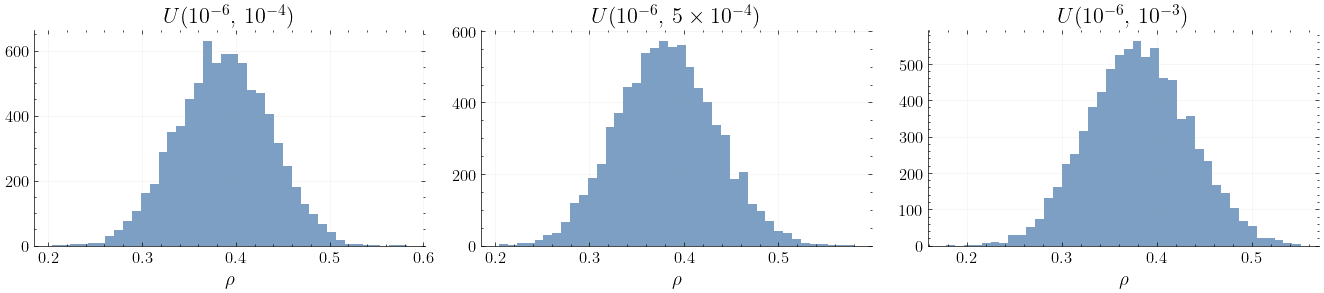

In [103]:
fig, axes = plt.subplots(1, len(caseB_variants), figsize=(4.5 * len(caseB_variants), 3.2), squeeze=False)
axes = axes.ravel()
for ax, (key, moments_i) in zip(axes, caseB_posterior_moments.items()):
    ax.hist(moments_i[:, -1], bins=40, color='#4477AA', alpha=0.7)
    ax.set_title(caseB_variants[key]['label'])
    ax.set_xlabel(r'$\rho$')
plt.tight_layout()
plt.show()

In [104]:
caseB_rho_lt_02_df = pd.DataFrame([
    {
        'dataset': caseB_variants[key]['label'],
        'Pr(rho < 0.2)': np.mean(moments_i[:, -1] < 0.2),
    }
    for key, moments_i in caseB_posterior_moments.items()
])
display(caseB_rho_lt_02_df.round(6))

,dataset,Pr(rho < 0.2)
0,"$U(10^{-6},\,10^{-4})$",0.000000
1,"$U(10^{-6},\,5 \times 10^{-4})$",0.000000
2,"$U(10^{-6},\,10^{-3})$",0.000125


In [105]:
caseB_posterior_mean_moments_df = pd.DataFrame([
    {
        'dataset': caseB_variants[key]['label'],
        'm1': moments_i.mean(axis=0)[0],
        'm2': moments_i.mean(axis=0)[1],
        'v1': moments_i.mean(axis=0)[2],
        'v2': moments_i.mean(axis=0)[3],
        'rho': moments_i.mean(axis=0)[4],
    }
    for key, moments_i in caseB_posterior_moments.items()
])
display(caseB_posterior_mean_moments_df.round(6))

caseB_posterior_mean_moments_df.loc[caseB_posterior_mean_moments_df['dataset'] == CASEB_DEFAULT_LABEL, ['m1', 'm2', 'v1', 'v2', 'rho']].to_numpy().ravel()

,dataset,m1,m2,v1,v2,rho
0,"$U(10^{-6},\,10^{-4})$",0.921850,0.934974,0.013967,0.011798,0.386956
1,"$U(10^{-6},\,5 \times 10^{-4})$",0.921126,0.935583,0.012570,0.010442,0.381666
2,"$U(10^{-6},\,10^{-3})$",0.919580,0.936754,0.012261,0.009839,0.381063


array([0.92112645, 0.93558308, 0.01256994, 0.01044232, 0.38166632])

In [106]:
caseB_posterior_median_moments_df = pd.DataFrame([
    {
        'dataset': caseB_variants[key]['label'],
        'm1': np.median(moments_i, axis=0)[0],
        'm2': np.median(moments_i, axis=0)[1],
        'v1': np.median(moments_i, axis=0)[2],
        'v2': np.median(moments_i, axis=0)[3],
        'rho': np.median(moments_i, axis=0)[4],
    }
    for key, moments_i in caseB_posterior_moments.items()
])
display(caseB_posterior_median_moments_df.round(6))

caseB_posterior_median_moments_df.loc[caseB_posterior_median_moments_df['dataset'] == CASEB_DEFAULT_LABEL, ['m1', 'm2', 'v1', 'v2', 'rho']].to_numpy().ravel()

,dataset,m1,m2,v1,v2,rho
0,"$U(10^{-6},\,10^{-4})$",0.922894,0.935892,0.013471,0.011367,0.387121
1,"$U(10^{-6},\,5 \times 10^{-4})$",0.922142,0.936693,0.012169,0.010079,0.381206
2,"$U(10^{-6},\,10^{-3})$",0.920582,0.937701,0.011821,0.009413,0.380471


array([0.9221419 , 0.93669336, 0.01216875, 0.010079  , 0.38120613])

## Comparing the models

In [107]:
from scipy.optimize import minimize
from scipy.special import expit, betaln
from scipy.stats import beta as beta_dist

def build_stan_data(x, y, use_priors=1):
    return {'n': x.shape[0], 'm': x.shape[0], 'xy': np.column_stack([x, y]).astype(float), 'use_priors': int(use_priors), 
            's_sigma1': 2, 's_sigma2': 2, 'tau': 5}

def extract_params_optimize(fit):
    mu = fit.stan_variable('mu')
    sigma1 = float(fit.stan_variable('sigma1'))
    sigma2 = float(fit.stan_variable('sigma2'))
    rho = float(fit.stan_variable('rho'))
    return np.r_[mu, sigma1, sigma2, rho]

def bln_bootstrap_mle(model_logit, x, y, B=200, seed=2421512):
    rng = np.random.default_rng(seed)
    n = len(x)
    params_boot = np.zeros((B, 5), dtype=float)
    idx_boot = np.zeros((B, n), dtype=int)
    for b in tqdm(range(B), desc="BLN bootstrap (optimize)", leave=False):
        idx = rng.choice(n, size=n, replace=True)
        idx_boot[b] = idx
        data_b = build_stan_data(x[idx], y[idx], use_priors=0)
        fit_b = model_logit.optimize(data=data_b, show_console=False)
        params_boot[b] = extract_params_optimize(fit_b)
    return params_boot, idx_boot

def bln_bayes_sample(model_logit, x, y, chains=4, draws=1000, seed=534523):
    data_bayes = build_stan_data(x, y, use_priors=1)
    fit = model_logit.sample(
        data=data_bayes,
        chains=chains,
        parallel_chains=min(chains, os.cpu_count() or 1),
        iter_sampling=draws,
        iter_warmup=max(500, draws//2),
        seed=seed,
        show_progress=True,
    )
    return fit

def bln_moments(mu1, mu2, sigma1, sigma2, rho, T=200000, seed=123):
    rng = np.random.default_rng(seed)
    Sigma = np.array([
        [sigma1**2, rho * sigma1 * sigma2],
        [rho * sigma1 * sigma2, sigma2**2]
    ])
    Z = rng.multivariate_normal(mean=[mu1, mu2], cov=Sigma, size=T)

    X = expit(Z[:, 0])
    Y = expit(Z[:, 1])

    m1 = X.mean()
    m2 = Y.mean()
    v1 = X.var(ddof=0)
    v2 = Y.var(ddof=0)
    rho_xy = np.corrcoef(X, Y)[0, 1]

    return np.array([m1, m2, v1, v2, rho_xy])

def beta_mom_start(z, eps=1e-6):
    z = np.clip(np.asarray(z, dtype=float), eps, 1 - eps)
    m = float(z.mean())
    v = float(z.var(ddof=0))
    scale = max(m * (1 - m) / max(v, eps) - 1, eps)
    return np.maximum(np.array([m * scale, (1 - m) * scale], dtype=float), eps)

def fit_beta_mle_1d(z, init=None, eps=1e-6):
    z = np.clip(np.asarray(z, dtype=float), eps, 1 - eps)
    init = beta_mom_start(z, eps=eps) if init is None else np.maximum(np.asarray(init, dtype=float), eps)

    def objective(log_params):
        a, b = np.exp(log_params)
        loglik = ((a - 1) * np.log(z) + (b - 1) * np.log1p(-z)).sum() - len(z) * betaln(a, b)
        return -float(loglik)

    res = minimize(objective, x0=np.log(init), method='L-BFGS-B')
    if not res.success:
        fallback = minimize(objective, x0=np.log(np.maximum(np.array([1.0, 1.0]), eps)), method='L-BFGS-B')
        res = fallback if fallback.success else res
    if not res.success:
        raise RuntimeError(f'Beta MLE failed: {res.message}')
    return np.exp(res.x)

def beta_mean_var(a, b):
    mean = a / (a + b)
    var = a * b / ((a + b) ** 2 * (a + b + 1))
    return float(mean), float(var)

def fit_independent_beta_mle(x, y):
    a1, b1 = fit_beta_mle_1d(x)
    a2, b2 = fit_beta_mle_1d(y)
    return np.array([a1, b1, a2, b2], dtype=float)

def independent_beta_moments(params):
    a1, b1, a2, b2 = np.asarray(params, dtype=float)
    m1, v1 = beta_mean_var(a1, b1)
    m2, v2 = beta_mean_var(a2, b2)
    return np.array([m1, m2, v1, v2, 0.0], dtype=float)

def independent_beta_tail_prob(params, thr=0.9):
    a1, b1, a2, b2 = np.asarray(params, dtype=float)
    return float(beta_dist.sf(thr, a1, b1) * beta_dist.sf(thr, a2, b2))

def independent_beta_pdf_point(x, y, params):
    if not (0 < x < 1 and 0 < y < 1):
        return 0.0
    a1, b1, a2, b2 = np.asarray(params, dtype=float)
    return float(beta_dist.pdf(x, a1, b1) * beta_dist.pdf(y, a2, b2))

def independent_beta_bootstrap_mle(x, y, B=200, seed=2421512):
    rng = np.random.default_rng(seed)
    n = len(x)
    params_boot = np.zeros((B, 4), dtype=float)
    for b in tqdm(range(B), desc="Indep. Beta bootstrap", leave=False):
        idx = rng.choice(n, size=n, replace=True)
        params_boot[b] = fit_independent_beta_mle(x[idx], y[idx])
    return params_boot

def independent_beta_ppc_moments_from_bootstrap(bootstrap_params, n_obs, take=None, seed=53241):
    rng = np.random.default_rng(seed)
    params = np.asarray(bootstrap_params, dtype=float)
    if take is not None and take < len(params):
        idx = rng.choice(len(params), size=take, replace=False)
        params = params[idx]
    draws = []
    for a1, b1, a2, b2 in params:
        X = rng.beta(a1, b1, size=n_obs)
        Y = rng.beta(a2, b2, size=n_obs)
        draws.append(sample_moments(X, Y))
    return np.vstack(draws)

def tail_from_independent_beta_bootstrap(bootstrap_params, thr=0.9, take=200, seed=87654):
    rng = np.random.default_rng(seed)
    params = np.asarray(bootstrap_params, dtype=float)
    if take is not None and take < len(params):
        idx = rng.choice(len(params), size=take, replace=False)
        params = params[idx]
    return np.array([independent_beta_tail_prob(params_i, thr=thr) for params_i in params], dtype=float)

def loo_logscore_independent_beta(x, y, seed=65432, B=50):
    rng = np.random.default_rng(seed)
    n = len(x)
    loo_scores = []
    for i in tqdm(range(n), leave=False):
        x_minus_i = np.delete(x, i)
        y_minus_i = np.delete(y, i)
        lp = 0.0
        for _ in range(B):
            idx = rng.choice(n - 1, size=n - 1, replace=True)
            params = fit_independent_beta_mle(x_minus_i[idx], y_minus_i[idx])
            lp += independent_beta_pdf_point(x[i], y[i], params) / B
        loo_scores.append(np.log(max(lp, 1e-300)))
    loo_scores = np.array(loo_scores, dtype=float)
    return float(loo_scores.mean()), loo_scores


In [108]:
B_BOOT = 500

bln_boot_params, bln_boot_indices = bln_bootstrap_mle(model_logit, x, y, B=B_BOOT, seed=2032125)

BLN bootstrap (optimize):   0%|          | 0/500 [00:00<?, ?it/s]

16:43:35 - cmdstanpy - INFO - Chain [1] start processing
16:43:35 - cmdstanpy - INFO - Chain [1] done processing
16:43:35 - cmdstanpy - INFO - Chain [1] start processing
16:43:35 - cmdstanpy - INFO - Chain [1] done processing
16:43:35 - cmdstanpy - INFO - Chain [1] start processing
16:43:35 - cmdstanpy - INFO - Chain [1] done processing
16:43:35 - cmdstanpy - INFO - Chain [1] start processing
16:43:35 - cmdstanpy - INFO - Chain [1] done processing
16:43:35 - cmdstanpy - INFO - Chain [1] start processing
16:43:35 - cmdstanpy - INFO - Chain [1] done processing
16:43:35 - cmdstanpy - INFO - Chain [1] start processing
16:43:35 - cmdstanpy - INFO - Chain [1] done processing
16:43:35 - cmdstanpy - INFO - Chain [1] start processing
16:43:35 - cmdstanpy - INFO - Chain [1] done processing
16:43:35 - cmdstanpy - INFO - Chain [1] start processing
16:43:35 - cmdstanpy - INFO - Chain [1] done processing
16:43:35 - cmdstanpy - INFO - Chain [1] start processing
16:43:36 - cmdstanpy - INFO - Chain [1]

In [109]:
bln_fit = bln_bayes_sample(model_logit, x, y, chains=4, draws=2000, seed=2023215)

bln_idata = az.from_cmdstanpy(
    posterior=bln_fit,
    log_likelihood='log_lik',
    posterior_predictive='xy_tilde',
    coords={'obs_id': np.arange(len(x))},
    dims={'log_lik': ['obs_id'], 'xy_tilde': ['ppc_id', 'dim']},
)

16:43:51 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

16:43:53 - cmdstanpy - INFO - CmdStan done processing.
16:43:53 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: logit_bivariate_model_model_namespace::log_prob: Sigma is not symmetric. Sigma[1,2] = inf, but Sigma[2,1] = inf (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/logit-bivariate-model.stan', line 27, column 4 to column 24)
	Exception: logit_bivariate_model_model_namespace::log_prob: Sigma is not symmetric. Sigma[1,2] = -inf, but Sigma[2,1] = -inf (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/logit-bivariate-model.stan', line 27, column 4 to column 24)
	Exception: logit_bivariate_model_model_namespace::log_prob: Sigma is not symmetric. Sigma[1,2] = -inf, but Sigma[2,1] = -inf (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/logit-bivariate-model.stan', line 27, column 4 to column 24)
	Exception: logit_bivariate_model_model_namespace::log_prob: Sigma is not symmetric. Sigma[1,2] = inf, but Sigma[2,1] = inf (in '

In [110]:
sample_moments = lambda x, y: np.array([np.mean(x), np.mean(y), np.var(x, ddof=0), np.var(y, ddof=0), np.corrcoef(x,y)[0,1]])

def tail_event_indicators(x, y, thr=0.9):
    return (x > thr) & (y > thr)

def brier_log_scores(ind, p, eps=1e-12):
    ind = ind.astype(float)
    p = np.clip(p, eps, 1 - eps)
    brier = float(np.mean((ind - p)**2))
    logsc = float(np.mean(ind * np.log(p) + (1 - ind) * np.log(1 - p)))
    return brier, logsc

def simulate_tail_prob_bibeta(alpha, T=20000, thr=0.9, rng=None):
    rng = np.random.default_rng(seed=84921) if rng is None else rng
    U = rng.dirichlet(alpha, size=T)
    X = U[:,0] + U[:,1]
    Y = U[:,0] + U[:,2]
    return float(np.mean((X > thr) & (Y > thr)))

def simulate_tail_prob_bln(params, T=20000, thr=0.9, rng=None):
    rng = np.random.default_rng(84921) if rng is None else rng
    mu1, mu2, sigma1, sigma2, rho = params
    Sigma = np.array([
        [sigma1**2, rho * sigma1 * sigma2],
        [rho * sigma1 * sigma2, sigma2**2]
    ])

    Z = rng.multivariate_normal(mean=[mu1, mu2], cov=Sigma, size=T)
    X = expit(Z[:, 0])
    Y = expit(Z[:, 1])

    return np.mean((X > thr) & (Y > thr))
    
def tail_from_posterior_predictive(idata, thr=0.9, take=1000):
    xy = idata.posterior_predictive['xy_tilde']
    arr = np.asarray(xy.stack(sample=('chain','draw')).transpose('sample','ppc_id','dim'))
    if arr.shape[0] > take:
        idx = np.random.default_rng(5324154).choice(arr.shape[0], size=take, replace=False)
        arr = arr[idx]
    p_draws = []
    for a in arr:
        X = np.asarray(a[:,0]); Y = np.asarray(a[:,1])
        p_draws.append(float(np.mean((X > thr) & (Y > thr))))
    return np.array(p_draws)

def tail_from_bibeta_bootstrap(bootstrap_alphas, thr=0.9, T=50000, take=200, seed=43532):
    rng = np.random.default_rng(seed)
    B = bootstrap_alphas.shape[0]
    idx = rng.choice(B, size=min(take, B), replace=False)
    p_list = []
    for i in tqdm(idx, desc="Tail from Beta bootstrap", leave=False):
        alpha = np.asarray(bootstrap_alphas[i], dtype=float)
        p_list.append(simulate_tail_prob_bibeta(alpha, T=T, thr=thr, rng=rng))
    return np.array(p_list)

def tail_from_bln_bootstrap(bootstrap_params, thr=0.9, T=50000, take=200, seed=87654):
    rng = np.random.default_rng(seed)
    B = bootstrap_params.shape[0]
    idx = rng.choice(B, size=min(take, B), replace=False)
    p_list = []
    for i in tqdm(idx, desc="Tail from BLN bootstrap", leave=False):
        params = np.asarray(bootstrap_params[i], dtype=float)
        p_list.append(simulate_tail_prob_bln(params, T=T, thr=thr, rng=rng))
    return np.array(p_list)

def bln_ppc_moments_from_idata(idata):
    xy = idata.posterior_predictive['xy_tilde']
    arr = np.asarray(xy.stack(sample=('chain','draw')).transpose('sample','ppc_id','dim'))
    mlist = []
    for a in arr:
        mlist.append(sample_moments(a[:,0], a[:,1]))
    return np.vstack(mlist)

def beta_ppc_moments_from_model_fit(model_fit):
    idata_beta = az.from_cmdstanpy(
        posterior=model_fit,
        posterior_predictive='xy_tilde',   # required for PPC moments
        coords={'obs_id': np.arange(len(x))},
        dims={'xy_tilde': ['ppc_id', 'dim']},
    )
    xy = idata_beta.posterior_predictive['xy_tilde']
    arr = np.asarray(xy.stack(sample=('chain','draw')).transpose('sample','ppc_id','dim'))
    mlist = []
    for a in arr:
        mlist.append(sample_moments(a[:,0], a[:,1]))
    return np.vstack(mlist), idata_beta

def z_scores_from_moment_draws(moment_draws, obs_mom):
    mu = moment_draws.mean(axis=0)
    sd = moment_draws.std(axis=0, ddof=1)
    z = (obs_mom - mu) / (sd + 1e-12)
    return z, mu, sd

def elpd_se_from_pointwise(loo_i):
    loo_i = np.asarray(loo_i, dtype=float)
    if loo_i.size < 2:
        return np.nan
    return float(np.sqrt(loo_i.size) * loo_i.std(ddof=1))

from scipy.special import gammaln
def pdf_bibeta(x, y, alpha, T=5000, rng=None):
    if not (0 < x < 1 and 0 < y < 1):
        return 0.0
    a1,a2,a3,a4 = alpha
    # bounds of integration
    lb = max(0, x+y-1)
    ub = min(x,y)
    rng = np.random.default_rng() if rng is None else rng
    U = rng.uniform(lb, ub, size=T)
    vals = (U**(a1-1) *
            (x-U)**(a2-1) *
            (y-U)**(a3-1) *
            (1-x-y+U)**(a4-1))
    integral = vals.mean() * (ub - lb)
    # normalization constant
    log_norm = gammaln(a1) + gammaln(a2) + gammaln(a3) + gammaln(a4) - gammaln(a1+a2+a3+a4)
    return integral / np.exp(log_norm)

def loo_logscore_bibeta(x, y, estimator, T=5000, seed=32, B=50, nu=None):
    rng = np.random.default_rng(seed)
    n = len(x)
    loo_scores = []
    for i in tqdm(range(n), leave=False):
        x_minus_i = np.delete(x,i); y_minus_i = np.delete(y,i)
        lp = 0.0
        for b in range(B):
            idx = rng.choice(n-1, size=n-1, replace=True)
            if nu is None:
                alpha_hat = estimator(x_minus_i[idx], y_minus_i[idx])
            else:
                alpha_hat = estimator(x_minus_i[idx], y_minus_i[idx], nu=nu)
            lp += pdf_bibeta(x[i], y[i], alpha_hat, T=T) / B
        loo_scores.append(np.log(max(lp, 1e-300)))
    loo_scores = np.array(loo_scores)
    return loo_scores.mean(), loo_scores

from scipy.special import logit
from scipy.stats import multivariate_normal
def pdf_bln_point(x, y, params):
    mu1, mu2, sigma1, sigma2, rho = params
    if not (0 < x < 1 and 0 < y < 1):
        return 0.0
    z1, z2 = logit(x), logit(y)
    cov = [[sigma1**2, rho*sigma1*sigma2],
           [rho*sigma1*sigma2, sigma2**2]]
    mvn_pdf = multivariate_normal.pdf([z1, z2], mean=[mu1, mu2], cov=cov, allow_singular=True)
    jac = 1.0 / (x*(1-x)*y*(1-y))
    return mvn_pdf * jac

def loo_logscore_bln(x, y, model_logit, seed=65432, B=50):
    rng = np.random.default_rng(seed)
    n = len(x)
    loo_scores = []
    for i in tqdm(range(n), leave=False):
        xy_minus_i = np.column_stack([np.delete(x,i), np.delete(y,i)])
        data_i = {'n': n-1, 'm': 0, 's_sigma1': 2.0, 's_sigma2': 2.0, 'tau': 5.0, 'use_priors': 0}
        lp = 0.0
        for b in range(B):
            idx = rng.choice(n-1, size=n-1, replace=True)
            data_i['xy'] = xy_minus_i[idx]
            fit_i = model_logit.optimize(data=data_i, seed=int(rng.integers(1e9)))
            mu, rho = fit_i.stan_variable('mu'), fit_i.stan_variable('rho')
            sigma1, sigma2 = fit_i.stan_variable('sigma1'), fit_i.stan_variable('sigma2')
            params = (mu[0], mu[1], sigma1, sigma2, rho)
            lp += pdf_bln_point(x[i], y[i], params) / B
        loo_scores.append(np.log(max(lp, 1e-300)))
    loo_scores = np.array(loo_scores)
    return loo_scores.mean(), loo_scores

## Visual posterior-predictive diagnostics

These helper functions add reviewer-facing visual checks comparing the OT bivariate-beta fit against the logit-normal benchmark through joint predictive contours and marginal Q-Q-style order-statistic diagnostics.

In [111]:
from pathlib import Path
from matplotlib import colors as mcolors
from scipy.stats import gaussian_kde


def posterior_predictive_array(idata, take=400, seed=12345):
    xy = idata.posterior_predictive['xy_tilde']
    arr = np.asarray(xy.stack(sample=('chain', 'draw')).transpose('sample', 'ppc_id', 'dim'), dtype=float)
    if arr.shape[0] > take:
        rng = np.random.default_rng(seed)
        idx = rng.choice(arr.shape[0], size=take, replace=False)
        arr = arr[idx]
    return arr


def pooled_ppc_points(idata, take=250, max_points=50000, seed=12345):
    arr = posterior_predictive_array(idata, take=take, seed=seed)
    points = arr.reshape(-1, 2)
    if points.shape[0] > max_points:
        rng = np.random.default_rng(seed + 1)
        idx = rng.choice(points.shape[0], size=max_points, replace=False)
        points = points[idx]
    return np.clip(points, 1e-6, 1 - 1e-6)


def hdr_contour_levels(z, probs=(0.5, 0.8, 0.95)):
    z = np.asarray(z, dtype=float)
    zflat = z.ravel()
    order = np.argsort(zflat)[::-1]
    z_sorted = zflat[order]
    cdf = np.cumsum(z_sorted)
    cdf /= cdf[-1]
    levels = []
    for prob in probs:
        idx = min(np.searchsorted(cdf, prob), len(z_sorted) - 1)
        levels.append(z_sorted[idx])
    return np.array(sorted(set(levels)), dtype=float)


def kde_on_grid(points, xlim, ylim, gridsize=160, seed=12345):
    xs = np.linspace(xlim[0], xlim[1], gridsize)
    ys = np.linspace(ylim[0], ylim[1], gridsize)
    xx, yy = np.meshgrid(xs, ys)
    eval_points = np.vstack([xx.ravel(), yy.ravel()])
    try:
        kde = gaussian_kde(points.T)
    except np.linalg.LinAlgError:
        rng = np.random.default_rng(seed)
        kde = gaussian_kde((points + rng.normal(scale=5e-4, size=points.shape)).T)
    zz = kde(eval_points).reshape(xx.shape)
    return xx, yy, zz


def add_joint_predictive_panel(ax, obs_x, obs_y, idata, model_label, color,
                               xlabel, ylabel, full_xlim, full_ylim,
                               contour_probs=(0.5, 0.8, 0.95), seed=12345):
    points = pooled_ppc_points(idata, take=250, max_points=50000, seed=seed)
    xx, yy, zz = kde_on_grid(points, full_xlim, full_ylim, gridsize=160, seed=seed)
    levels = hdr_contour_levels(zz, probs=contour_probs)

    ax.scatter(obs_x, obs_y, s=20, color='black', alpha=0.62, linewidths=0, zorder=3)
    fill_colors = [mcolors.to_rgba(color, alpha=a) for a in (0.16, 0.28, 0.42)]
    ax.contourf(xx, yy, zz, levels=np.r_[levels, zz.max()], colors=fill_colors, antialiased=True, zorder=1)
    ax.contour(xx, yy, zz, levels=levels, colors=[color] * len(levels), linewidths=(0.85, 1.05, 1.25), zorder=2)
    ax.set_xlim(*full_xlim)
    ax.set_ylim(*full_ylim)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(model_label, fontsize=15)
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.3)


def add_marginal_qq_panel(ax, obs, beta_idata, bln_idata, dim, xlabel,
                          beta_label='OT bivariate-beta', bln_label='Logit-normal',
                          beta_color='#0072B2', bln_color='#D55E00',
                          interval=(0.1, 0.9), seed=12345):
    obs_sorted = np.sort(np.asarray(obs, dtype=float))
    beta_arr = posterior_predictive_array(beta_idata, take=400, seed=seed)
    bln_arr = posterior_predictive_array(bln_idata, take=400, seed=seed + 17)

    beta_sorted = np.sort(beta_arr[:, :, dim], axis=1)
    bln_sorted = np.sort(bln_arr[:, :, dim], axis=1)

    beta_lo, beta_med, beta_hi = np.quantile(beta_sorted, [interval[0], 0.5, interval[1]], axis=0)
    bln_lo, bln_med, bln_hi = np.quantile(bln_sorted, [interval[0], 0.5, interval[1]], axis=0)

    lo = min(obs_sorted.min(), beta_lo.min(), bln_lo.min())
    hi = max(obs_sorted.max(), beta_hi.max(), bln_hi.max())
    pad = 0.04 * (hi - lo if hi > lo else 1.0)

    ax.fill_betweenx(obs_sorted, beta_lo, beta_hi, color=beta_color, alpha=0.18)
    ax.plot(beta_med, obs_sorted, color=beta_color, linewidth=2.0, label=beta_label)

    ax.fill_betweenx(obs_sorted, bln_lo, bln_hi, color=bln_color, alpha=0.15)
    ax.plot(bln_med, obs_sorted, color=bln_color, linewidth=2.0, label=bln_label)

    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], linestyle='--', color='black', linewidth=1.0, label='45-degree line')
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel('Model quantiles')
    ax.set_ylabel('Observed quantiles')
    ax.set_title(f'{xlabel} marginal', fontsize=15)
    ax.tick_params(axis='both', labelsize=11)
    ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.3)


def plot_ot_vs_bln_visual_diagnostics(x, y, beta_idata, bln_idata, case_label,
                                      xlabel, ylabel, figure_path,
                                      beta_label='OT bivariate-beta',
                                      bln_label='Logit-normal'):
    beta_color = '#0072B2'
    bln_color = '#D55E00'

    obs_x = np.asarray(x, dtype=float)
    obs_y = np.asarray(y, dtype=float)
    lower = max(0.0, min(obs_x.min(), obs_y.min()) - 0.05)
    full_xlim = (lower, 1.0)
    full_ylim = (lower, 1.0)

    fig, axes = plt.subplots(2, 2, figsize=(8.8, 6.8), constrained_layout=True)

    add_joint_predictive_panel(
        axes[0, 0], obs_x, obs_y, beta_idata, beta_label, beta_color,
        xlabel, ylabel, full_xlim, full_ylim, seed=20260331,
    )
    add_joint_predictive_panel(
        axes[0, 1], obs_x, obs_y, bln_idata, bln_label, bln_color,
        xlabel, ylabel, full_xlim, full_ylim, seed=20260401,
    )

    add_marginal_qq_panel(
        axes[1, 0], obs_x, beta_idata, bln_idata, dim=0, xlabel=xlabel,
        beta_label=beta_label, bln_label=bln_label,
        beta_color=beta_color, bln_color=bln_color, seed=20260331,
    )
    add_marginal_qq_panel(
        axes[1, 1], obs_y, beta_idata, bln_idata, dim=1, xlabel=ylabel,
        beta_label=beta_label, bln_label=bln_label,
        beta_color=beta_color, bln_color=bln_color, seed=20260401,
    )

    axes[1, 1].legend(frameon=True, loc='lower right', fontsize=10)

    figure_path = Path(figure_path)
    figure_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(figure_path, bbox_inches='tight')
    plt.show()


<!-- PRIOR_SENSITIVITY_HELPERS -->
## Prior sensitivity helpers

The following cells define the 8-prior matrix requested by the reviewer, reuse the existing CmdStan/ArviZ/BivariateBeta workflow, and save per-case summaries under `../experiments/sensitivity/`.


In [112]:
from pathlib import Path

PRIOR_SENSITIVITY_OUTPUT_DIR = Path('../experiments/sensitivity')
PRIOR_SENSITIVITY_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PRIOR_SENSITIVITY_CONFIGS = [
    {
        'id': 'P_0',
        'label': 'Baseline',
        'theta_prior': np.array([1.0, 1.0, 1.0, 1.0]),
        's_family': 'lognormal',
        's_params': {'s_mu': 4.0, 's_sd': 1.0},
        'justification': 'Weakly informative, flat baseline.',
    },
    {
        'id': 'P_1',
        'label': 'Gamma',
        'theta_prior': np.array([1.0, 1.0, 1.0, 1.0]),
        's_family': 'gamma',
        's_params': {'kappa': 4.0, 'lambda': 1.0},
        'justification': 'Shape sensitivity.',
    },
    {
        'id': 'P_2',
        'label': 'Vague',
        'theta_prior': np.array([0.5, 0.5, 0.5, 0.5]),
        's_family': 'lognormal',
        's_params': {'s_mu': 4.0, 's_sd': 2.0},
        'justification': 'Jeffreys-like, very broad.',
    },
    {
        'id': 'P_3',
        'label': 'Sparse',
        'theta_prior': np.array([0.1, 0.1, 0.1, 0.1]),
        's_family': 'lognormal',
        's_params': {'s_mu': 4.0, 's_sd': 1.0},
        'justification': 'Favors extreme or polarized values.',
    },
    {
        'id': 'P_4',
        'label': 'Indep.',
        'theta_prior': np.array([10.0, 10.0, 10.0, 10.0]),
        's_family': 'lognormal',
        's_params': {'s_mu': 4.0, 's_sd': 1.0},
        'justification': 'Bias toward zero correlation.',
    },
    {
        'id': 'P_5',
        'label': 'Adversarial',
        'theta_prior': np.array([1.0, 2.0, 2.0, 1.0]),
        's_family': 'lognormal',
        's_params': {'s_mu': 4.0, 's_sd': 1.0},
        'justification': 'Bias toward negative correlation.',
    },
    {
        'id': 'P_6',
        'label': 'Strong s',
        'theta_prior': np.array([1.0, 1.0, 1.0, 1.0]),
        's_family': 'lognormal',
        's_params': {'s_mu': 4.0, 's_sd': 0.2},
        'justification': 'Low variance on concentration.',
    },
    {
        'id': 'P_7',
        'label': 'Asym-Vague',
        'theta_prior': np.array([1.0, 2.0, 0.5, 1.0]),
        's_family': 'gamma',
        's_params': {'kappa': 2.0, 'lambda': 0.5},
        'justification': 'Asymmetric and highly broad.',
    },
]
PRIOR_SENSITIVITY_ORDER = [cfg['id'] for cfg in PRIOR_SENSITIVITY_CONFIGS]
MOMENT_ORDER = ['m1', 'v1', 'm2', 'v2', 'rho']


def format_dirichlet_prior(theta_prior):
    theta_text = ', '.join(f'{float(value):g}' for value in theta_prior)
    return f'Dir({theta_text})'


def format_scale_prior(prior_cfg):
    if prior_cfg['s_family'] == 'lognormal':
        return f"LN(log {prior_cfg['s_params']['s_mu']:g}, {prior_cfg['s_params']['s_sd']:g})"
    return f"Gamma({prior_cfg['s_params']['kappa']:g}, {prior_cfg['s_params']['lambda']:g})"


def build_bivariate_beta_prior_data(x, y, prior_cfg):
    data = {
        'n': int(len(x)),
        'xy': np.column_stack([x, y]).astype(float),
        'a': np.asarray(prior_cfg['theta_prior'], dtype=float),
    }
    data.update(prior_cfg['s_params'])
    return data


def select_bivariate_beta_model(prior_cfg):
    if prior_cfg['s_family'] == 'lognormal':
        return model_lognormal
    if prior_cfg['s_family'] == 'gamma':
        return model_gamma
    raise ValueError(f"Unknown prior family: {prior_cfg['s_family']}")


def beta_idata_from_fit(model_fit, n_obs):
    return az.from_cmdstanpy(
        posterior=model_fit,
        posterior_predictive='xy_tilde',
        coords={'obs_id': np.arange(n_obs)},
        dims={'xy_tilde': ['ppc_id', 'dim']},
    )


def implied_moment_draws_from_alpha(alpha_draws):
    distribution = BivariateBeta(np.ones(4))
    draws = [distribution.moments(alpha) for alpha in np.asarray(alpha_draws, dtype=float)]
    moment_df = pd.DataFrame(draws, columns=['m1', 'm2', 'v1', 'v2', 'rho'])
    return moment_df[MOMENT_ORDER]


def summarize_hmc_diagnostics(model_fit, idata):
    sampler_summary = az.summary(idata, var_names=['alpha', 's'])
    sampler_vars = {}
    try:
        sampler_vars = model_fit.method_variables()
    except Exception:
        sampler_vars = {}

    divergences = np.asarray(sampler_vars.get('divergent__', []), dtype=float).reshape(-1) if isinstance(sampler_vars, dict) else np.array([])
    bfmi_values = np.atleast_1d(np.asarray(az.bfmi(idata), dtype=float))

    return {
        'divergences': int(divergences.sum()) if divergences.size else 0,
        'max_rhat': float(sampler_summary['r_hat'].max()) if 'r_hat' in sampler_summary.columns else np.nan,
        'min_bulk_ess': float(sampler_summary['ess_bulk'].min()) if 'ess_bulk' in sampler_summary.columns else np.nan,
        'min_tail_ess': float(sampler_summary['ess_tail'].min()) if 'ess_tail' in sampler_summary.columns else np.nan,
        'bfmi_min': float(np.min(bfmi_values)) if bfmi_values.size else np.nan,
        'bfmi_mean': float(np.mean(bfmi_values)) if bfmi_values.size else np.nan,
    }


def summarize_prior_sensitivity_fit(model_fit, idata, prior_cfg, x, y, tail_threshold=0.9, include_pr_rho_negative=False, loo_cache=None):
    alpha_draws = np.asarray(model_fit.stan_variable('alpha'), dtype=float)
    moment_draws = implied_moment_draws_from_alpha(alpha_draws)
    rho_draws = moment_draws['rho'].to_numpy()
    rho_interval = np.asarray(az.hdi(rho_draws, hdi_prob=0.95), dtype=float)

    loo_res = beta_bayes_loo_from_model_fit(model_fit, cache=loo_cache, take=400, seed=20260331, n_quad=48, batch_size=256)
    pareto_k = np.asarray(getattr(loo_res, 'pareto_k', np.array([])), dtype=float)
    tail_draws = tail_from_posterior_predictive(idata, thr=tail_threshold, take=1000)
    diagnostics = summarize_hmc_diagnostics(model_fit, idata)

    summary_row = {
        'prior_id': prior_cfg['id'],
        'label': prior_cfg['label'],
        'theta_prior': format_dirichlet_prior(prior_cfg['theta_prior']),
        's_prior': format_scale_prior(prior_cfg),
        'justification': prior_cfg['justification'],
        'status': 'ok',
        'rho_median': float(np.median(rho_draws)),
        'rho_ci_low': float(rho_interval[0]),
        'rho_ci_high': float(rho_interval[1]),
        'elpd_loo': float(loo_res.elpd_loo),
        'elpd_se': float(loo_res.se),
        'p_loo': float(loo_res.p_loo),
        'pareto_k_max': float(np.max(pareto_k)) if pareto_k.size else np.nan,
        'pareto_k_bad': int(np.sum(pareto_k > 0.7)) if pareto_k.size else 0,
        'tail_prob_mean': float(np.mean(tail_draws)),
        'tail_prob_sd': float(np.std(tail_draws, ddof=1)),
        'empirical_tail_prob': float(np.mean((x > tail_threshold) & (y > tail_threshold))),
        'pr_rho_lt_0': float(np.mean(rho_draws < 0)) if include_pr_rho_negative else np.nan,
        **diagnostics,
    }

    moment_summary = moment_draws.agg(['mean', 'median']).T.loc[MOMENT_ORDER]
    moment_rows = []
    for moment_name, row in moment_summary.iterrows():
        moment_rows.append({
            'prior_id': prior_cfg['id'],
            'label': prior_cfg['label'],
            'moment': moment_name,
            'posterior_mean': float(row['mean']),
            'posterior_median': float(row['median']),
        })

    return summary_row, moment_rows, moment_draws, tail_draws


def plot_prior_sensitivity_overview(summary_df, case_label, figure_path):
    ok_df = summary_df.loc[summary_df['status'].fillna('ok') == 'ok'].copy()
    if ok_df.empty:
        print(f'No successful sensitivity fits available for {case_label}.')
        return None

    ok_df['prior_id'] = pd.Categorical(ok_df['prior_id'], categories=PRIOR_SENSITIVITY_ORDER, ordered=True)
    ok_df = ok_df.sort_values('prior_id').reset_index(drop=True)
    prior_ids = ok_df['prior_id'].astype(str).tolist()
    y = np.arange(len(ok_df))

    fig, (label_ax, rho_ax, elpd_ax) = plt.subplots(
        1,
        3,
        figsize=(8.6, max(2.35, 0.30 * len(ok_df) + 0.45)),
        constrained_layout=True,
        gridspec_kw={'width_ratios': [0.3, 3.1, 3.1]},
    )

    label_ax.set_xlim(0.0, 1.0)
    label_ax.set_ylim(-0.5, len(ok_df) - 0.5)
    label_ax.invert_yaxis()
    for yi, prior_id, in enumerate(prior_ids):
        label_ax.text(0.00, yi, r'${}$'.format(prior_id), va='center', ha='left', fontsize=10, fontweight='bold')
    label_ax.set_title('Prior', loc='left')
    label_ax.axis('off')

    rho_ax.set_ylim(-0.5, len(ok_df) - 0.5)
    rho_ax.invert_yaxis()
    rho_ax.set_yticks(y)
    rho_ax.set_yticklabels([])
    rho_xerr = np.vstack([
        ok_df['rho_median'] - ok_df['rho_ci_low'],
        ok_df['rho_ci_high'] - ok_df['rho_median'],
    ])
    rho_ax.errorbar(ok_df['rho_median'], y, xerr=rho_xerr, fmt='o', color='#4477AA', ecolor='#4477AA', capsize=3)
    rho_ax.axvline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.6)
    rho_ax.set_xlabel(r'Posterior $\rho$')
    rho_ax.set_title('Correlation sensitivity')

    elpd_ax.set_ylim(-0.5, len(ok_df) - 0.5)
    elpd_ax.invert_yaxis()
    elpd_ax.set_yticks(y)
    elpd_ax.set_yticklabels([])
    baseline_elpd = ok_df.loc[ok_df['prior_id'].astype(str) == 'P_0', 'elpd_loo'].dropna()
    elpd_ax.errorbar(ok_df['elpd_loo'], y, xerr=ok_df['elpd_se'], fmt='o', color='#228833', ecolor='#228833', capsize=3)
    if not baseline_elpd.empty:
        elpd_ax.axvline(float(baseline_elpd.iloc[0]), color='black', linestyle='--', linewidth=1.0, alpha=0.6)
    elpd_ax.set_xlabel('PSIS-LOO ELPD')
    elpd_ax.set_title('Predictive fit')

    fig.savefig(figure_path, bbox_inches='tight')
    plt.show()
    return fig


def run_prior_sensitivity_case(
    case_id,
    case_label,
    x,
    y,
    include_pr_rho_negative=False,
    tail_threshold=0.9,
    chains=4,
    iter_sampling=2000,
    iter_warmup=2000,
    adapt_delta=0.99,
    seed_base=20260330,
):
    summary_rows = []
    moment_rows = []
    compact_draws = {}
    loo_cache = build_beta_loglik_cache(x, y, n_quad=48)

    for prior_offset, prior_cfg in enumerate(PRIOR_SENSITIVITY_CONFIGS):
        print(f"[{case_id}] Running {prior_cfg['id']} ({prior_cfg['label']})")
        try:
            model = select_bivariate_beta_model(prior_cfg)
            stan_data = build_bivariate_beta_prior_data(x, y, prior_cfg)
            model_fit = model.sample(
                data=stan_data,
                chains=chains,
                parallel_chains=min(chains, os.cpu_count() or 1),
                iter_sampling=iter_sampling,
                iter_warmup=iter_warmup,
                adapt_delta=prior_cfg.get('adapt_delta', adapt_delta),
                seed=int(seed_base + prior_offset),
                show_progress=True,
            )
            idata = beta_idata_from_fit(model_fit, n_obs=len(x))
            summary_row, moment_rows_i, moment_draws_i, tail_draws_i = summarize_prior_sensitivity_fit(
                model_fit=model_fit,
                idata=idata,
                prior_cfg=prior_cfg,
                x=x,
                y=y,
                tail_threshold=tail_threshold,
                include_pr_rho_negative=include_pr_rho_negative,
                loo_cache=loo_cache,
            )
            summary_rows.append(summary_row)
            moment_rows.extend(moment_rows_i)
            compact_draws[prior_cfg['id']] = {
                'rho_draws': moment_draws_i['rho'].to_numpy(),
                'tail_draws': np.asarray(tail_draws_i, dtype=float),
            }
        except Exception as exc:
            summary_rows.append({
                'prior_id': prior_cfg['id'],
                'label': prior_cfg['label'],
                'theta_prior': format_dirichlet_prior(prior_cfg['theta_prior']),
                's_prior': format_scale_prior(prior_cfg),
                'justification': prior_cfg['justification'],
                'status': 'failed',
                'error': str(exc),
            })

    summary_df = pd.DataFrame(summary_rows)
    if not summary_df.empty and 'prior_id' in summary_df.columns:
        summary_df['prior_id'] = pd.Categorical(summary_df['prior_id'], categories=PRIOR_SENSITIVITY_ORDER, ordered=True)
        summary_df = summary_df.sort_values('prior_id').reset_index(drop=True)
        baseline_elpd = summary_df.loc[summary_df['prior_id'].astype(str) == 'P_0', 'elpd_loo'].dropna() if 'elpd_loo' in summary_df.columns else pd.Series(dtype=float)
        if not baseline_elpd.empty:
            summary_df['delta_elpd_vs_p0'] = summary_df['elpd_loo'] - float(baseline_elpd.iloc[0])
        else:
            summary_df['delta_elpd_vs_p0'] = np.nan

    moments_df = pd.DataFrame(moment_rows)
    if not moments_df.empty:
        moments_df['prior_id'] = pd.Categorical(moments_df['prior_id'], categories=PRIOR_SENSITIVITY_ORDER, ordered=True)
        moments_df['moment'] = pd.Categorical(moments_df['moment'], categories=MOMENT_ORDER, ordered=True)
        moments_df = moments_df.sort_values(['prior_id', 'moment']).reset_index(drop=True)
        moments_wide = moments_df.pivot(index=['prior_id', 'label'], columns='moment', values=['posterior_mean', 'posterior_median'])
        moments_wide = moments_wide.loc[:, [('posterior_mean', moment) for moment in MOMENT_ORDER] + [('posterior_median', moment) for moment in MOMENT_ORDER]]
        moments_wide.columns = [f'{stat}_{moment}' for stat, moment in moments_wide.columns]
        moments_wide = moments_wide.reset_index()
    else:
        moments_wide = pd.DataFrame(columns=['prior_id', 'label'])

    summary_path = PRIOR_SENSITIVITY_OUTPUT_DIR / f'{case_id}_prior_sensitivity_summary.csv'
    moments_path = PRIOR_SENSITIVITY_OUTPUT_DIR / f'{case_id}_prior_sensitivity_moments.csv'
    summary_df.to_csv(summary_path, index=False)
    moments_wide.to_csv(moments_path, index=False)

    return {
        'case_id': case_id,
        'case_label': case_label,
        'summary': summary_df,
        'moments': moments_wide,
        'draws': compact_draws,
        'summary_path': summary_path,
        'moments_path': moments_path,
    }

def beta_ppc_moments_from_fit_and_xy(model_fit, x, y):
    idata_beta = beta_idata_from_fit(model_fit, n_obs=len(x))
    xy_ppc = idata_beta.posterior_predictive['xy_tilde']
    arr = np.asarray(xy_ppc.stack(sample=('chain', 'draw')).transpose('sample', 'ppc_id', 'dim'))
    mlist = []
    for a in arr:
        mlist.append(sample_moments(a[:, 0], a[:, 1]))
    return np.vstack(mlist), idata_beta


def run_caseB_model_comparison(dataset, beta_fit, bln_fit, bln_idata, bootstrap_samples_1, bootstrap_samples_4, bln_boot_params):
    x_local = dataset['x']
    y_local = dataset['y']
    obs_mom = sample_moments(x_local, y_local)
    beta_moment_draws, beta_idata = beta_ppc_moments_from_fit_and_xy(beta_fit, x_local, y_local)
    beta_loo_cache = build_beta_loglik_cache(x_local, y_local, n_quad=48)

    results = {}

    loo_res = beta_bayes_loo_from_model_fit(beta_fit, cache=beta_loo_cache, take=1000, seed=654322, n_quad=48, batch_size=256)
    results['beta_bayes'] = {
        'elpd': {
            'elpd_loo': float(loo_res.elpd_loo),
            'se': float(loo_res.se),
            'p_loo': float(loo_res.p_loo),
            'loo_i': loo_res.loo_i.values,
        },
        'moments': {},
    }
    results['beta_bayes']['moments']['Z'], results['beta_bayes']['moments']['mean'], results['beta_bayes']['moments']['sd'] = z_scores_from_moment_draws(beta_moment_draws, obs_mom)
    p_tail_draws = tail_from_posterior_predictive(beta_idata, thr=0.9, take=1000)
    results['beta_bayes']['tail'] = {
        'p_mean': float(p_tail_draws.mean()),
        'p_sd': float(p_tail_draws.std(ddof=1)),
        'p_draws': p_tail_draws,
    }

    bln_moment_draws = bln_ppc_moments_from_idata(bln_idata)
    loo_res = az.loo(bln_idata, pointwise=True)
    results['bln_bayes'] = {
        'elpd': {
            'elpd_loo': float(loo_res.elpd_loo),
            'se': float(loo_res.se),
            'p_loo': float(loo_res.p_loo),
            'loo_i': loo_res.loo_i.values,
        },
        'moments': {},
    }
    results['bln_bayes']['moments']['Z'], results['bln_bayes']['moments']['mean'], results['bln_bayes']['moments']['sd'] = z_scores_from_moment_draws(bln_moment_draws, obs_mom)
    p_tail_draws_bln = tail_from_posterior_predictive(bln_idata, thr=0.9, take=1000)
    results['bln_bayes']['tail'] = {
        'p_mean': float(p_tail_draws_bln.mean()),
        'p_sd': float(p_tail_draws_bln.std(ddof=1)),
        'p_draws': p_tail_draws_bln,
    }

    mom_list = [BivariateBeta(a).moments() for a in bootstrap_samples_1.T]
    mom_draws = np.asarray(mom_list, dtype=float)
    _, loo_scores_bibeta = loo_logscore_bibeta(x_local, y_local, distribution.method_moments_estimator_1, seed=654321, T=20000, nu=1e-8)
    results['mom_closed'] = {
        'elpd': {
            'elpd_loo': float(loo_scores_bibeta.sum()),
            'se': elpd_se_from_pointwise(loo_scores_bibeta),
            'p_loo': None,
            'loo_i': loo_scores_bibeta,
        },
        'moments': {},
    }
    Z, mu_mom, sd_mom = z_scores_from_moment_draws(mom_draws, obs_mom)
    results['mom_closed']['moments'] = {'Z': Z, 'mean': mu_mom, 'sd': sd_mom}
    p_tail_draws_m1 = tail_from_bibeta_bootstrap(bootstrap_samples_1.T, thr=0.9, T=40000, take=1000)
    results['mom_closed']['tail'] = {'p_mean': float(p_tail_draws_m1.mean()), 'p_sd': float(p_tail_draws_m1.std(ddof=1)), 'p_draws': p_tail_draws_m1}

    mom_list = [BivariateBeta(a).moments() for a in bootstrap_samples_4.T]
    mom_draws = np.asarray(mom_list, dtype=float)
    _, loo_scores_bibeta = loo_logscore_bibeta(x_local, y_local, distribution.method_moments_estimator_4, seed=654321)
    results['mom_nls'] = {
        'elpd': {
            'elpd_loo': float(loo_scores_bibeta.sum()),
            'se': elpd_se_from_pointwise(loo_scores_bibeta),
            'p_loo': None,
            'loo_i': loo_scores_bibeta,
        },
        'moments': {},
    }
    Z, mu_mom, sd_mom = z_scores_from_moment_draws(mom_draws, obs_mom)
    results['mom_nls']['moments'] = {'Z': Z, 'mean': mu_mom, 'sd': sd_mom}
    p_tail_draws_m4 = tail_from_bibeta_bootstrap(bootstrap_samples_4.T, thr=0.9, T=40000, take=1000)
    results['mom_nls']['tail'] = {'p_mean': float(p_tail_draws_m4.mean()), 'p_sd': float(p_tail_draws_m4.std(ddof=1)), 'p_draws': p_tail_draws_m4}

    mle_list = [bln_moments(mu1=a[0], mu2=a[1], sigma1=a[2], sigma2=a[3], rho=a[4]) for a in bln_boot_params]
    mle_draws = np.asarray(mle_list, dtype=float)
    _, loo_scores_bln = loo_logscore_bln(x_local, y_local, model_logit, seed=654321)
    results['mle'] = {
        'elpd': {
            'elpd_loo': float(loo_scores_bln.sum()),
            'se': elpd_se_from_pointwise(loo_scores_bln),
            'p_loo': None,
            'loo_i': loo_scores_bln,
        },
        'moments': {},
    }
    Z, mu_mle, sd_mle = z_scores_from_moment_draws(mle_draws, obs_mom)
    results['mle']['moments'] = {'Z': Z, 'mean': mu_mle, 'sd': sd_mle}
    p_tail_draws = tail_from_bln_bootstrap(bln_boot_params, thr=0.9, T=40000, take=1000)
    results['mle']['tail'] = {'p_mean': float(p_tail_draws.mean()), 'p_sd': float(p_tail_draws.std(ddof=1)), 'p_draws': p_tail_draws}

    ind_tail = tail_event_indicators(x_local, y_local, thr=0.9).astype(int)
    tail_rows = []
    for model_name in ['beta_bayes', 'bln_bayes', 'mom_closed', 'mom_nls', 'mle']:
        p_mean = float(np.mean(results[model_name]['tail']['p_draws']))
        brier, logscore = brier_log_scores(ind_tail, p_mean)
        tail_rows.append({'model': model_name, 'p_tail': p_mean, 'brier': brier, 'logscore': logscore})

    elpd_rows = []
    for model_name in ['beta_bayes', 'bln_bayes', 'mom_closed', 'mom_nls', 'mle']:
        elpd_rows.append({
            'model': model_name,
            'elpd': results[model_name]['elpd']['elpd_loo'],
            'elpd_se': results[model_name]['elpd']['se'],
        })

    z_rows = []
    for model_name in ['beta_bayes', 'bln_bayes', 'mom_closed', 'mom_nls', 'mle']:
        z = results[model_name]['moments']['Z']
        z_rows.append({
            'model': model_name,
            'm1': z[0],
            'm2': z[1],
            'v1': z[2],
            'v2': z[3],
            'rho': z[4],
        })

    return {
        'results': results,
        'obs_mom': obs_mom,
        'beta_idata': beta_idata,
        'tail_df': pd.DataFrame(tail_rows),
        'elpd_df': pd.DataFrame(elpd_rows),
        'z_df': pd.DataFrame(z_rows),
    }


In [119]:
obs_mom = sample_moments(x, y)
beta_moment_draws, beta_idata = beta_ppc_moments_from_model_fit(model_fit)
beta_loo_cache = build_beta_loglik_cache(x, y, n_quad=48)

loo_res = beta_bayes_loo_from_model_fit(model_fit, cache=beta_loo_cache, take=1000, seed=654322, n_quad=48, batch_size=256)
results = {}
results['beta_bayes'] = {
    'elpd': {
        'elpd_loo': float(loo_res.elpd_loo),
        'se': float(loo_res.se),
        'p_loo': float(loo_res.p_loo),
        'loo_i': loo_res.loo_i.values,
    },
    'moments': {},
}

results['beta_bayes']['moments']['Z'], \
results['beta_bayes']['moments']['mean'], \
results['beta_bayes']['moments']['sd'] = z_scores_from_moment_draws(beta_moment_draws, obs_mom)

# Tail distribution, Brier/Log scores
p_tail_draws = tail_from_posterior_predictive(beta_idata, thr=0.9, take=1000)
results['beta_bayes']['tail'] = {
    'p_mean': float(p_tail_draws.mean()),
    'p_sd':   float(p_tail_draws.std(ddof=1)),
    'p_draws': p_tail_draws,
}

In [34]:
bln_moment_draws = bln_ppc_moments_from_idata(bln_idata)

loo_res = az.loo(bln_idata, pointwise=True)
results['bln_bayes'] = {
    'elpd': {
        'elpd_loo': float(loo_res.elpd_loo),
        'se': float(loo_res.se),
        'p_loo': float(loo_res.p_loo),
        'loo_i': loo_res.loo_i.values,
    },
    'moments': {},
}

results['bln_bayes']['moments']['Z'], \
results['bln_bayes']['moments']['mean'], \
results['bln_bayes']['moments']['sd'] = z_scores_from_moment_draws(bln_moment_draws, obs_mom)

p_tail_draws_bln = tail_from_posterior_predictive(bln_idata, thr=0.9, take=1000)
results['bln_bayes']['tail'] = {
    'p_mean': float(p_tail_draws_bln.mean()),
    'p_sd':   float(p_tail_draws_bln.std(ddof=1)),
    'p_draws': p_tail_draws_bln,
}

In [35]:
mom_list = []
for a in bootstrap_samples_1.T:
    mom_list.append(BivariateBeta(a).moments())
mom_draws = np.asarray(mom_list, dtype=float)

mean_logscore_bibeta, loo_scores_bibeta = loo_logscore_bibeta(x, y, distribution.method_moments_estimator_1, seed=654321, T=20000, nu=1e-8)
results['mom_closed'] = {
    'elpd': {
        'elpd_loo': float(loo_scores_bibeta.sum()),
        'se': elpd_se_from_pointwise(loo_scores_bibeta),
        'p_loo': None,
        'loo_i': loo_scores_bibeta,
    },
    'moments': {},
}

Z, mu_mom, sd_mom = z_scores_from_moment_draws(mom_draws, obs_mom)
results['mom_closed']['moments'] = {'Z': Z, 'mean': mu_mom, 'sd': sd_mom}

p_tail_draws_m1 = tail_from_bibeta_bootstrap(bootstrap_samples_1.T, thr=0.9, T=40000, take=1000)
results['mom_closed']['tail'] = {
    'p_mean': float(p_tail_draws_m1.mean()),
    'p_sd':   float(p_tail_draws_m1.std(ddof=1)),
    'p_draws': p_tail_draws_m1,
}

  0%|          | 0/71 [00:00<?, ?it/s]

Tail from Beta bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

In [36]:
mom_list = []
for a in bootstrap_samples_4.T:
    mom_list.append(BivariateBeta(a).moments())
mom_draws = np.asarray(mom_list, dtype=float)

mean_logscore_bibeta, loo_scores_bibeta = loo_logscore_bibeta(x, y, distribution.method_moments_estimator_4, seed=654321)
results['mom_nls'] = {
    'elpd': {
        'elpd_loo': float(loo_scores_bibeta.sum()),
        'se': elpd_se_from_pointwise(loo_scores_bibeta),
        'p_loo': None,
        'loo_i': loo_scores_bibeta,
    },
    'moments': {},
}

Z, mu_mom, sd_mom = z_scores_from_moment_draws(mom_draws, obs_mom)
results['mom_nls']['moments'] = {'Z': Z, 'mean': mu_mom, 'sd': sd_mom}

p_tail_draws_m4 = tail_from_bibeta_bootstrap(bootstrap_samples_4.T, thr=0.9, T=40000, take=1000)
results['mom_nls']['tail'] = {
    'p_mean': float(p_tail_draws_m4.mean()),
    'p_sd':   float(p_tail_draws_m4.std(ddof=1)),
    'p_draws': p_tail_draws_m4,
}

  0%|          | 0/71 [00:00<?, ?it/s]

Tail from Beta bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

In [37]:
mle_list = []
for a in bln_boot_params:
    mle_list.append(bln_moments(mu1=a[0], mu2=a[1], sigma1=a[2], sigma2=a[3], rho=a[4]))
mle_draws = np.asarray(mle_list, dtype=float)

mean_logscore_bln, loo_scores_bln = loo_logscore_bln(x, y, model_logit, seed=654321)
results['mle'] = {
    'elpd': {
        'elpd_loo': float(loo_scores_bln.sum()),
        'se': elpd_se_from_pointwise(loo_scores_bln),
        'p_loo': None,
        'loo_i': loo_scores_bln,
    },
    'moments': {},
}

Z, mu_mle, sd_mle = z_scores_from_moment_draws(mle_draws, obs_mom)
results['mle']['moments'] = {'Z': Z, 'mean': mu_mle, 'sd': sd_mle}

p_tail_draws = tail_from_bln_bootstrap(bln_boot_params, thr=0.9, T=40000, take=1000)
results['mle']['tail'] = {
    'p_mean': float(p_tail_draws.mean()),
    'p_sd':   float(p_tail_draws.std(ddof=1)),
    'p_draws': p_tail_draws,
}

  0%|          | 0/71 [00:00<?, ?it/s]

15:42:20 - cmdstanpy - INFO - Chain [1] start processing
15:42:20 - cmdstanpy - INFO - Chain [1] done processing
15:42:20 - cmdstanpy - INFO - Chain [1] start processing
15:42:20 - cmdstanpy - INFO - Chain [1] done processing
15:42:20 - cmdstanpy - INFO - Chain [1] start processing
15:42:20 - cmdstanpy - INFO - Chain [1] done processing
15:42:20 - cmdstanpy - INFO - Chain [1] start processing
15:42:20 - cmdstanpy - INFO - Chain [1] done processing
15:42:20 - cmdstanpy - INFO - Chain [1] start processing
15:42:20 - cmdstanpy - INFO - Chain [1] done processing
15:42:20 - cmdstanpy - INFO - Chain [1] start processing
15:42:20 - cmdstanpy - INFO - Chain [1] done processing
15:42:20 - cmdstanpy - INFO - Chain [1] start processing
15:42:20 - cmdstanpy - INFO - Chain [1] done processing
15:42:20 - cmdstanpy - INFO - Chain [1] start processing
15:42:20 - cmdstanpy - INFO - Chain [1] done processing
15:42:20 - cmdstanpy - INFO - Chain [1] start processing
15:42:20 - cmdstanpy - INFO - Chain [1]

Tail from BLN bootstrap:   0%|          | 0/500 [00:00<?, ?it/s]

### Reviewer benchmark: independent marginal Betas

This block fits two independent Beta marginals to Case B by marginal MLE, reports the implied `(m_1, v_1, m_2, v_2, \rho)` with `\rho = 0`, and adds the benchmark to the comparison diagnostics and figure.


In [38]:
caseB_model_order = ['beta_bayes', 'ind_beta_mle', 'bln_bayes', 'mom_closed', 'mom_nls', 'mle']

ind_beta_boot_params = independent_beta_bootstrap_mle(x, y, B=B_BOOT, seed=2032126)
ind_beta_mle_hat = fit_independent_beta_mle(x, y)
ind_beta_moment_draws = independent_beta_ppc_moments_from_bootstrap(
    ind_beta_boot_params,
    n_obs=len(x),
    take=min(500, len(ind_beta_boot_params)),
    seed=2032127,
)

_, loo_scores_ind_beta = loo_logscore_independent_beta(x, y, seed=654321, B=50)
results['ind_beta_mle'] = {
    'elpd': {
        'elpd_loo': float(loo_scores_ind_beta.sum()),
        'se': elpd_se_from_pointwise(loo_scores_ind_beta),
        'p_loo': None,
        'loo_i': loo_scores_ind_beta,
    },
    'moments': {},
    'params': ind_beta_mle_hat,
}

Z, mu_ind_beta, sd_ind_beta = z_scores_from_moment_draws(ind_beta_moment_draws, obs_mom)
results['ind_beta_mle']['moments'] = {
    'Z': Z,
    'mean': mu_ind_beta,
    'sd': sd_ind_beta,
}

p_tail_draws = tail_from_independent_beta_bootstrap(
    ind_beta_boot_params,
    thr=0.9,
    take=min(1000, len(ind_beta_boot_params)),
    seed=2032128,
)
results['ind_beta_mle']['tail'] = {
    'p_mean': float(p_tail_draws.mean()),
    'p_sd': float(p_tail_draws.std(ddof=1)),
    'p_draws': p_tail_draws,
}

a1_hat, b1_hat, a2_hat, b2_hat = ind_beta_mle_hat
m1_hat, v1_hat = beta_mean_var(a1_hat, b1_hat)
m2_hat, v2_hat = beta_mean_var(a2_hat, b2_hat)
ind_beta_summary_df = pd.DataFrame([
    {
        'model': 'ind_beta_mle',
        'a1_hat': a1_hat,
        'b1_hat': b1_hat,
        'a2_hat': a2_hat,
        'b2_hat': b2_hat,
        'm1_hat': m1_hat,
        'v1_hat': v1_hat,
        'm2_hat': m2_hat,
        'v2_hat': v2_hat,
        'rho_hat': 0.0,
    }
])
print('Independent Beta marginal MLE benchmark:')
display(ind_beta_summary_df.round(6))


Indep. Beta bootstrap:   0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/71 [00:00<?, ?it/s]

Independent Beta marginal MLE benchmark:


,model,a1_hat,b1_hat,a2_hat,b2_hat,m1_hat,v1_hat,m2_hat,v2_hat,rho_hat
0,ind_beta_mle,7.509755,0.414024,4.398842,0.300549,0.947749,0.005549,0.936045,0.010504,0.0


In [39]:
ind_tail = tail_event_indicators(x, y, thr=0.9).astype(int)

if 'caseB_model_order' not in globals():
    caseB_model_order = ['beta_bayes', 'ind_beta_mle', 'bln_bayes', 'mom_closed', 'mom_nls', 'mle']

def summarize_brier_log(name, p_draws_or_scalar):
    # use mean p (Bayes) or scalar; Brier/log scores against empirical indicators
    if np.ndim(p_draws_or_scalar) == 0:
        p = float(p_draws_or_scalar)
        b,l = brier_log_scores(ind_tail, p)
        return {'p': p, 'brier': b, 'logscore': l}
    else:
        p_mean = float(np.mean(p_draws_or_scalar))
        b,l = brier_log_scores(ind_tail, p_mean)
        return {'p': p_mean, 'brier': b, 'logscore': l}

summary_rows = []
for model_name in caseB_model_order:
    s = summarize_brier_log(model_name, results[model_name]['tail']['p_draws'])
    summary_rows.append([model_name, s['p'], s['brier'], s['logscore']])

summary_df = pd.DataFrame(summary_rows, columns=['model','p_tail','brier','logscore'])
print("Tail-event summary (p_hat, Brier, Log-score):")
display(summary_df)


Tail-event summary (p_hat, Brier, Log-score):


,model,p_tail,brier,logscore
0,beta_bayes,0.642437,0.212110,-0.615798
1,ind_beta_mle,0.655266,0.210689,-0.612681
2,bln_bayes,0.663775,0.209928,-0.610987
3,mom_closed,0.666195,0.209738,-0.610561
4,mom_nls,0.374223,0.317193,-0.830833
5,mle,0.640039,0.212412,-0.616454


In [40]:
if 'caseB_model_order' not in globals():
    caseB_model_order = ['beta_bayes', 'ind_beta_mle', 'bln_bayes', 'mom_closed', 'mom_nls', 'mle']

elpd_rows = []
for model_name in caseB_model_order:
    elpd_rows.append([model_name, results[model_name]['elpd']['elpd_loo'], results[model_name]['elpd']['se']])
elpd_df = pd.DataFrame(elpd_rows, columns=['model','elpd','elpd_se'])
print("ELPD (Bayes PSIS-LOO and Freq bootstrap-LOO):")
display(elpd_df)


ELPD (Bayes PSIS-LOO and Freq bootstrap-LOO):


,model,elpd,elpd_se
0,beta_bayes,320.725033,26.311904
1,ind_beta_mle,339.701010,24.847007
2,bln_bayes,331.748224,27.264943
3,mom_closed,-489.660424,51.543552
4,mom_nls,-1276.464362,130.046176
5,mle,322.416850,27.668092


In [41]:
def pack_z(model_key, label):
    if model_key not in results: 
        return None
    Z = results[model_key]['moments']['Z']
    mu = results[model_key]['moments']['mean']
    sd = results[model_key]['moments']['sd']
    cols = ['m1','m2','v1','v2','rho']
    row = [label] + list(Z)
    return row, cols

if 'caseB_model_order' not in globals():
    caseB_model_order = ['beta_bayes', 'ind_beta_mle', 'bln_bayes', 'mom_closed', 'mom_nls', 'mle']

z_rows = []
for key in caseB_model_order:
    out = pack_z(key, key)
    if out:
        z_rows.append(out[0])
        cols = out[1]
if z_rows:
    z_df = pd.DataFrame(z_rows, columns=['model'] + cols)
    print("Standardized moment misfit Z-scores (observed vs model-implied):")
    display(z_df)


Standardized moment misfit Z-scores (observed vs model-implied):


,model,m1,m2,v1,v2,rho
0,beta_bayes,1.466101,0.469870,-1.582412,1.487483,-3.130038
1,ind_beta_mle,-0.221991,0.386695,-0.382146,0.836865,-1.587803
2,bln_bayes,1.153986,0.569308,-1.714049,-0.591903,-1.598104
3,mom_closed,0.031611,-0.027257,0.034670,8.314513,-9.650342
4,mom_nls,2.347896,1.659217,-1.580583,1.378234,-2.230909
5,mle,0.695383,0.546333,-0.783281,-0.548773,-1.001262


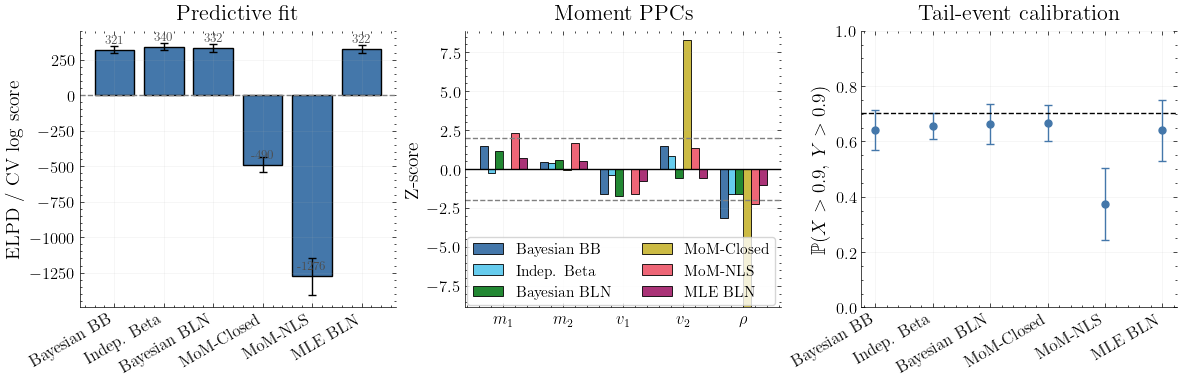

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

# -------------------- styling (paper-friendly) --------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.15,
    "grid.linestyle": "-",
})

# Colorblind-friendly palette (Tol's "bright")
COLORS = ["#4477AA", "#66CCEE", "#228833", "#CCBB44", "#EE6677", "#AA3377"]

# -------------------- model order & labels --------------------
models = OrderedDict([
    ("beta_bayes",   "Bayesian BB"),
    ("ind_beta_mle", "Indep. Beta"),
    ("bln_bayes",    "Bayesian BLN"),
    ("mom_closed",   "MoM-Closed"),
    ("mom_nls",      "MoM-NLS"),
    ("mle",          "MLE BLN"),
])
methods = list(models.values())
xpos = np.arange(len(methods))
method_colors = dict(zip(methods, COLORS))
bar_colors = [method_colors[label] for label in methods]

# -------------------- pull numbers from your `results` --------------------
elpd_means = [float(results[k]['elpd']['elpd_loo']) for k in models.keys()]
elpd_se    = [float(results[k]['elpd']['se'])       for k in models.keys()]

moment_labels = [r"$m_1$", r"$m_2$", r"$v_1$", r"$v_2$", r"$\rho$"]
moments = {models[k]: np.asarray(results[k]['moments']['Z'], float) for k in models.keys()}

tail_mean = [float(results[k]['tail']['p_mean']) for k in models.keys()]
tail_sd   = [float(results[k]['tail']['p_sd'])   for k in models.keys()]
empirical_tail = float(np.mean((x > 0.9) & (y > 0.9)))

# -------------------- figure --------------------
fig, axes = plt.subplots(1, 3, figsize=(11.8, 3.8), constrained_layout=True)

# ========== Panel 1: Predictive fit ==========
ax = axes[0]
bars = ax.bar(
    xpos, elpd_means, yerr=elpd_se, capsize=3, linewidth=1.0,
    edgecolor="black", color=COLORS[0]
)
ax.axhline(0, color="0.5", linestyle="--", linewidth=1)
ax.set_xticks(xpos)
ax.set_xticklabels(methods, rotation=30, ha="right")
ax.set_ylabel("ELPD / CV log score")
ax.set_title("Predictive fit", pad=8)

for rect in bars:
    ax.annotate(f"{rect.get_height():.0f}",
                xy=(rect.get_x() + rect.get_width()/2, rect.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, color="0.3")

# ========== Panel 2: Moment PPC Z-scores ==========
ax = axes[1]
width = 0.13
for j, method in enumerate(methods):
    zvals = moments[method]
    ax.bar(np.arange(len(moment_labels)) + j*width, zvals,
           width=width, label=method, color=method_colors[method], edgecolor="black", linewidth=0.6)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(2, color="0.5", linestyle="--", linewidth=1)
ax.axhline(-2, color="0.5", linestyle="--", linewidth=1)
ax.set_xticks(np.arange(len(moment_labels)) + width * (len(methods) - 1) / 2)
ax.set_xticklabels(moment_labels)
ax.set_ylabel("Z-score")
ax.set_title("Moment PPCs", pad=8)
ax.legend(ncol=2, frameon=True, loc="lower left", bbox_to_anchor=(-0.02, -0.02))

z_all = np.concatenate([moments[m] for m in methods])
z_lim = np.percentile(np.abs(z_all), 98)
ax.set_ylim(-max(2, z_lim), max(2, z_lim))

# ========== Panel 3: Tail-event calibration ==========
ax = axes[2]
for xpos_i, mean_i, sd_i, color_i, label_i in zip(xpos, tail_mean, tail_sd, bar_colors, methods):
    ax.errorbar([xpos_i], [mean_i], yerr=[sd_i], fmt='o', ms=5,
                elinewidth=1.0, capsize=3, color=COLORS[0], label=label_i)
ax.axhline(empirical_tail, color="black", linestyle="--", linewidth=1, label="Empirical")
ax.set_xticks(xpos)
ax.set_xticklabels(methods, rotation=30, ha="right")
ax.set_ylabel(r"$\mathbb{P}(X > 0.9,\, Y > 0.9)$")
lo = min(min(tail_mean) - 2*max(tail_sd), 0.0)
hi = max(max(tail_mean) + 2*max(tail_sd), 1.0)
ax.set_ylim(max(0.0, lo), min(1.0, hi))
ax.set_title("Tail-event calibration", pad=8)

# -------------------- save (vector + raster) --------------------
plt.savefig("../figures/caseB_comparison.pdf", bbox_inches="tight")
plt.show()


### Visual diagnostics for the OT fit versus the logit-normal

These reviewer-facing diagnostics compare the two Bayesian models directly through joint posterior-predictive contours and marginal Q-Q-style order-statistic plots.

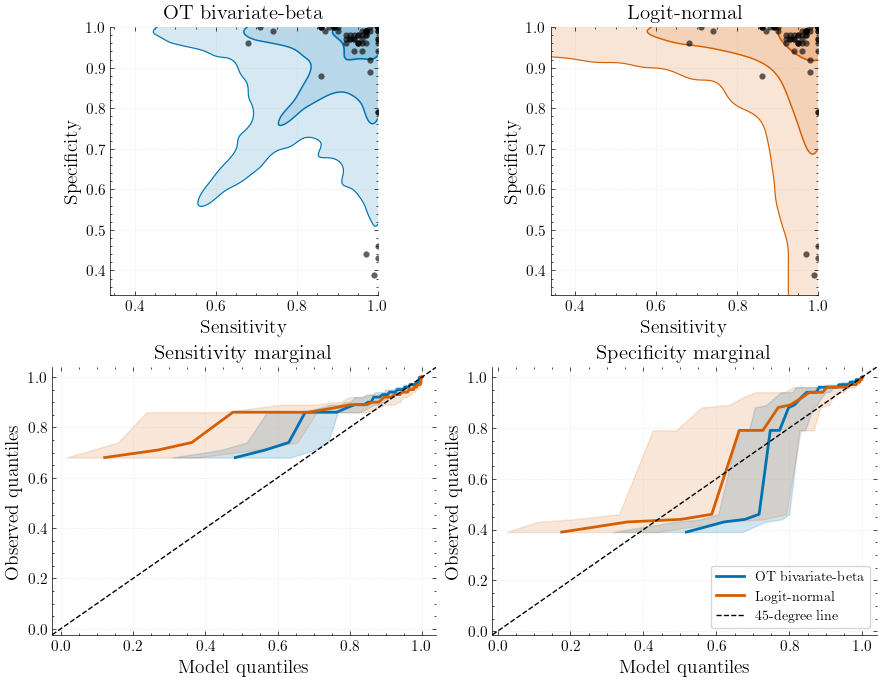

In [120]:
plot_ot_vs_bln_visual_diagnostics(
    x=x,
    y=y,
    beta_idata=beta_idata,
    bln_idata=bln_idata,
    case_label=f'Case B: ANVISA COVID-19 diagnostic tests ({CASEB_DEFAULT_LABEL})',
    xlabel='Sensitivity',
    ylabel='Specificity',
    figure_path='../figures/caseB_visual_diagnostics.pdf',
)

<!-- PRIOR_SENSITIVITY_CASE_B -->
## Prior sensitivity analysis

This block reruns the Bayesian OT bivariate-beta fit for Case B under the full 8-prior matrix and saves reviewer-facing outputs to `../experiments/sensitivity/caseB_prior_sensitivity_*.csv`.


In [44]:
# PRIOR_SENSITIVITY_CASE_B
caseB_prior_sensitivity = run_prior_sensitivity_case(
    case_id='caseB',
    case_label=f'Case B: ANVISA COVID-19 diagnostic tests ({CASEB_DEFAULT_LABEL})',
    x=x,
    y=y,
    include_pr_rho_negative=True,
    tail_threshold=0.9,
    seed_base=202603300,
)

print(f"Saved summary to {caseB_prior_sensitivity['summary_path']}")
print(f"Saved implied moments to {caseB_prior_sensitivity['moments_path']}")
display(caseB_prior_sensitivity['summary'].round(4))
display(caseB_prior_sensitivity['moments'].round(4))

15:46:49 - cmdstanpy - INFO - CmdStan start processing


[caseB] Running P_0 (Baseline)


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

15:55:24 - cmdstanpy - INFO - CmdStan done processing.
15:55:24 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Random variable is 0, but must be positive finite! (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/bivariate-beta-model-gamma.stan', line 56, column 3 to column 28)
Consider re-running with show_console=True if the above output is unclear!



Saved summary to ../experiments/sensitivity/caseB_prior_sensitivity_summary.csv
Saved implied moments to ../experiments/sensitivity/caseB_prior_sensitivity_moments.csv


,prior_id,label,theta_prior,s_prior,justification,status,rho_median,rho_ci_low,rho_ci_high,elpd_loo,...,tail_prob_sd,empirical_tail_prob,pr_rho_lt_0,divergences,max_rhat,min_bulk_ess,min_tail_ess,bfmi_min,bfmi_mean,delta_elpd_vs_p0
0,P_0,Baseline,"Dir(1, 1, 1, 1)","LN(log 4, 1)","Weakly informative, flat baseline.",ok,0.3836,0.2762,0.4819,320.8439,...,0.0695,0.7042,0.0,0,1.0,4908.0,5764.0,0.7467,0.7699,0.0000
1,P_1,Gamma,"Dir(1, 1, 1, 1)","Gamma(4, 1)",Shape sensitivity.,ok,0.3821,0.2815,0.4865,320.7796,...,0.0733,0.7042,0.0,0,1.0,3788.0,4859.0,0.8093,0.8182,-0.0643
2,P_2,Vague,"Dir(0.5, 0.5, 0.5, 0.5)","LN(log 4, 2)","Jeffreys-like, very broad.",ok,0.3829,0.2837,0.4894,320.8085,...,0.0694,0.7042,0.0,0,1.0,4026.0,5644.0,0.7466,0.7767,-0.0354
3,P_3,Sparse,"Dir(0.1, 0.1, 0.1, 0.1)","LN(log 4, 1)",Favors extreme or polarized values.,ok,0.3828,0.2848,0.4864,321.1360,...,0.0704,0.7042,0.0,0,1.0,4091.0,4995.0,0.7919,0.8025,0.2921
4,P_4,Indep.,"Dir(10, 10, 10, 10)","LN(log 4, 1)",Bias toward zero correlation.,ok,0.3583,0.2599,0.4548,312.2112,...,0.0706,0.7042,0.0,0,1.0,4849.0,5524.0,0.7622,0.7679,-8.6326
5,P_5,Adversarial,"Dir(1, 2, 2, 1)","LN(log 4, 1)",Bias toward negative correlation.,ok,0.3737,0.2685,0.4739,321.0091,...,0.0739,0.7042,0.0,0,1.0,4366.0,5853.0,0.7460,0.7603,0.1652
6,P_6,Strong s,"Dir(1, 1, 1, 1)","LN(log 4, 0.2)",Low variance on concentration.,ok,0.3799,0.2828,0.4873,320.5399,...,0.0663,0.7042,0.0,0,1.0,4103.0,5363.0,0.7553,0.7758,-0.3040
7,P_7,Asym-Vague,"Dir(1, 2, 0.5, 1)","Gamma(2, 0.5)",Asymmetric and highly broad.,ok,0.3783,0.2743,0.4759,321.1951,...,0.0704,0.7042,0.0,0,1.0,3592.0,4832.0,0.7928,0.8137,0.3513


,prior_id,label,posterior_mean_m1,posterior_mean_v1,posterior_mean_m2,posterior_mean_v2,posterior_mean_rho,posterior_median_m1,posterior_median_v1,posterior_median_m2,posterior_median_v2,posterior_median_rho
0,P_0,Baseline,0.9211,0.0125,0.9357,0.0104,0.3840,0.9219,0.0122,0.9365,0.0100,0.3836
1,P_1,Gamma,0.9199,0.0129,0.9346,0.0108,0.3823,0.9207,0.0125,0.9355,0.0104,0.3821
2,P_2,Vague,0.9231,0.0120,0.9373,0.0099,0.3829,0.9239,0.0116,0.9381,0.0096,0.3829
3,P_3,Sparse,0.9247,0.0116,0.9387,0.0096,0.3830,0.9257,0.0112,0.9394,0.0093,0.3828
4,P_4,Indep.,0.8648,0.0317,0.8858,0.0275,0.3577,0.8666,0.0308,0.8873,0.0267,0.3583
5,P_5,Adversarial,0.9183,0.0134,0.9331,0.0111,0.3746,0.9193,0.0129,0.9339,0.0108,0.3737
6,P_6,Strong s,0.9169,0.0139,0.9318,0.0116,0.3800,0.9177,0.0136,0.9327,0.0113,0.3799
7,P_7,Asym-Vague,0.9208,0.0128,0.9342,0.0108,0.3786,0.9217,0.0124,0.9351,0.0104,0.3783


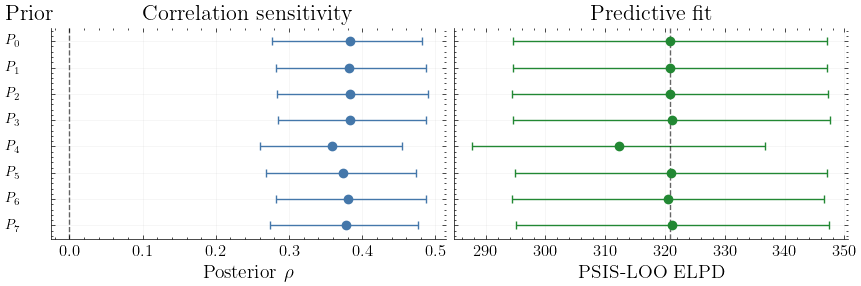

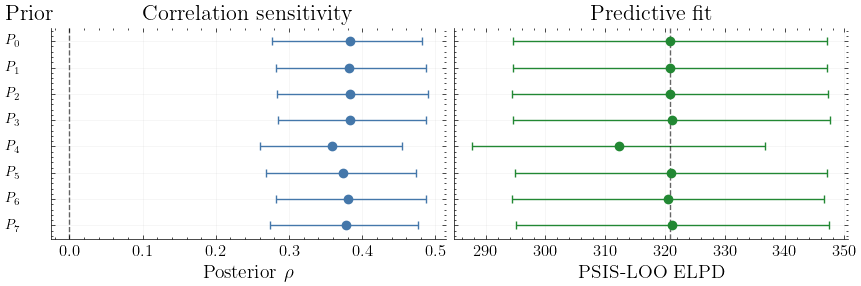

In [45]:
plot_prior_sensitivity_overview(
    caseB_prior_sensitivity['summary'],
    case_label=caseB_prior_sensitivity['case_label'],
    figure_path=Path('../figures/caseB_prior_sensitivity.pdf'),
)

# Share of immunized children

## Fitting the model

In [46]:
df_dtp = pd.read_csv('../data/share-of-children-immunized-dtp3/share-of-children-immunized-dtp3.csv',
                     names=['Entity', 'Code', 'Year', 'Share'], header=0)
df_measles = pd.read_csv('../data/share-of-children-vaccinated-against-measles/share-of-children-vaccinated-against-measles.csv',
                         names=['Entity', 'Code', 'Year', 'Share'], header=0)
df = pd.merge(left=df_dtp, right=df_measles, on=['Entity', 'Code', 'Year'])
df.dropna(inplace=True)
df = df[df['Year'] == 2024]
df['Share_x'] = df['Share_x']/100; df['Share_y'] = df['Share_y']/100

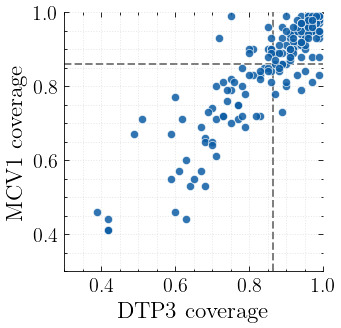

In [47]:
m1 = df['Share_x'].mean()
m2 = df['Share_y'].mean()

plt.figure(figsize=(4,3), dpi=120)

plt.axvline(m1, linestyle='--', linewidth=1.2, color='black', alpha=0.5, zorder=1)
plt.axhline(m2, linestyle='--', linewidth=1.2, color='black', alpha=0.5, zorder=1)

plt.scatter(df['Share_x'],
            df['Share_y'],
            marker='o', s=24, alpha=0.85, zorder=2, edgecolor='white', linewidth=0.4)

plt.xlim(0.3,1)
plt.ylim(0.3,1)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('DTP3 coverage', fontsize=14); plt.ylabel('MCV1 coverage', fontsize=14)
plt.grid(True, which='both', linestyle=':', linewidth=0.6, alpha=0.3)
plt.tick_params(axis='both', labelsize=12)
plt.tight_layout()

plt.savefig('../figures/share_children_vaccination_dtp3_mcv1.pdf', bbox_inches='tight')
plt.show()

In [48]:
distribution = BivariateBeta()

x = df.Share_x.values.copy()
y = df.Share_y.values.copy()
rng = np.random.default_rng(seed=13)
eps = 0.000001
x[x==y] += rng.uniform(-eps, eps, size=np.sum(x==y))

m1 = np.mean(x)
m2 = np.mean(y)
v1 = np.var(x, ddof=0)
v2 = np.var(y, ddof=0)
rho = np.corrcoef(x, y)[0,1]

moments = [m1, m2, v1, v2, rho]
moments

[0.8654872002376152,
 0.858871794871795,
 0.01685553729319297,
 0.019965906640368174,
 0.85493038606162]

In [49]:
(df.Share_x.values == df.Share_y.values).mean()

0.14358974358974358

Bootstrap correlation

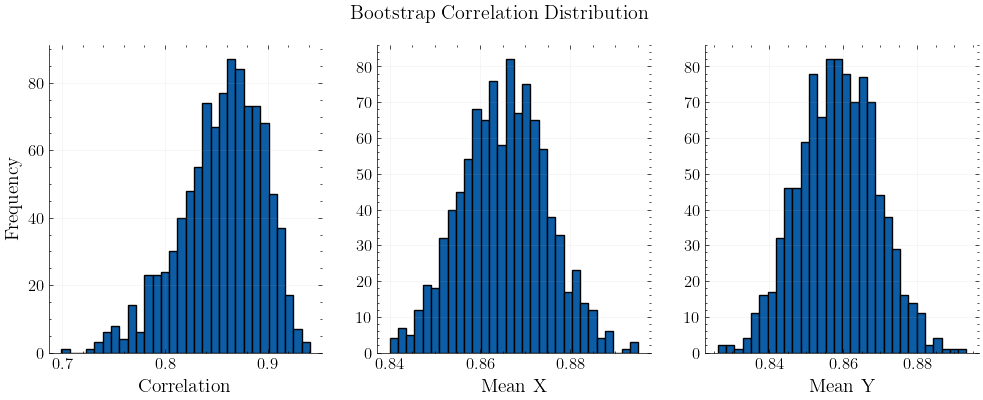

In [50]:
rng = np.random.default_rng(seed=3921)
n_bootstrap = 1000
boot_corrs = []
boot_m1 = []
boot_m2 = []

for _ in range(n_bootstrap):
    indices = rng.integers(0, len(x), len(x))
    sample_x = x[indices]
    sample_y = y[indices]
    corr = np.corrcoef(sample_x, sample_y)[0, 1]
    boot_m1.append(sample_x.mean())
    boot_m2.append(sample_y.mean())
    boot_corrs.append(corr)

boot_corrs = np.array(boot_corrs)

fig, ax = plt.subplots(1,3,figsize=(12,4))
ax[0].hist(boot_corrs, bins=30, edgecolor="black")
ax[1].hist(boot_m1, bins=30, edgecolor="black")
ax[2].hist(boot_m2, bins=30, edgecolor="black")
ax[0].set_xlabel("Correlation")
ax[1].set_xlabel("Mean X")
ax[2].set_xlabel("Mean Y")
ax[0].set_ylabel("Frequency")
fig.suptitle("Bootstrap Correlation Distribution")
plt.show()

In [51]:
m1*(1-m1)/v1 - m2*(1-m2)/v2

0.8359754154201617

In [52]:
alpha_hat1 = distribution.method_moments_estimator_1(x, y)
BivariateBeta(alpha_hat1).moments()

array([0.8654872 , 0.85887179, 0.01685554, 0.01754933, 0.85493039])

In [53]:
alpha_hat4 = distribution.method_moments_estimator_4(x, y)
BivariateBeta(alpha_hat4).moments()

array([0.86562282, 0.85874438, 0.01804914, 0.01882227, 0.85493047])

In [54]:
distribution.marginal_diagnostic(x,y)

(1.1355299967145147, 0.2561533208708595)

In [55]:
distribution.positive_diagnostic_diagnostic(x,y)

0.013971290961035249

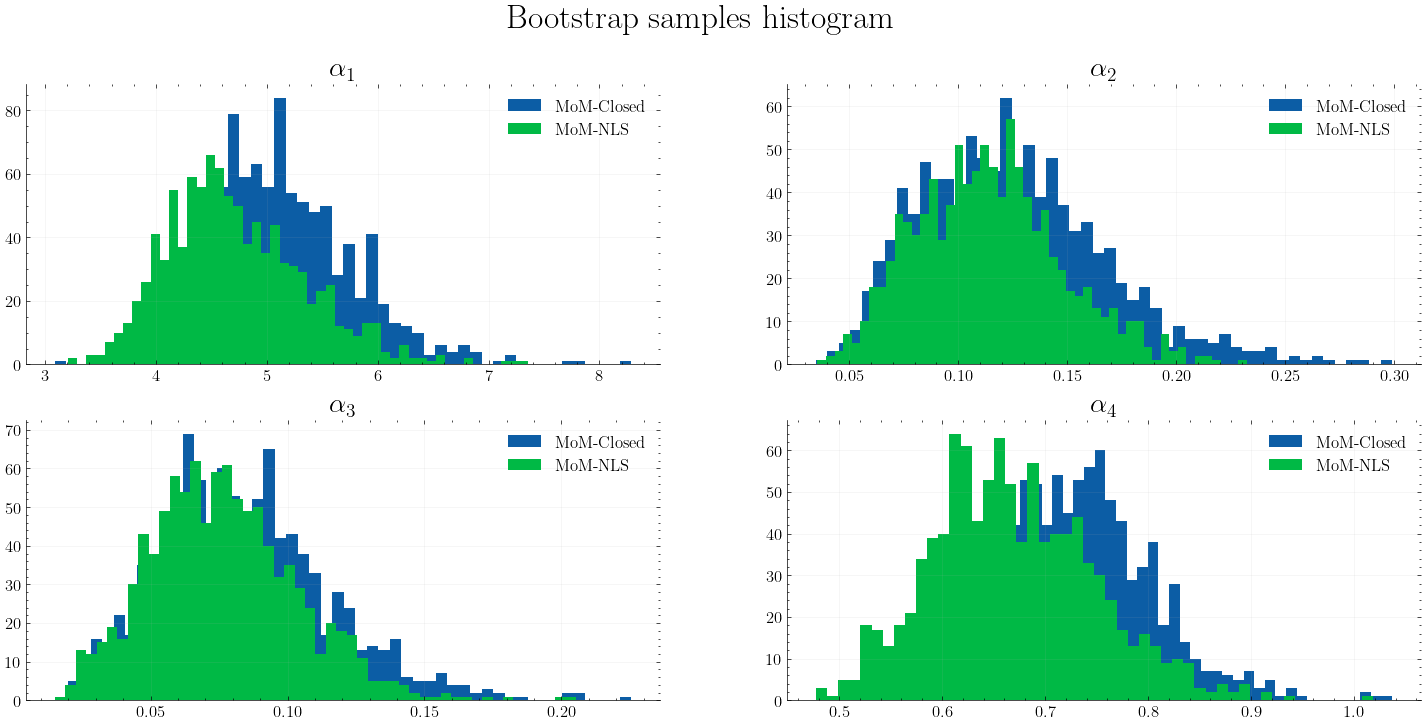

In [56]:
bootstrap_samples_1 = distribution.bootstrap_method(x, y, B=1000, method=distribution.method_moments_estimator_1)
bootstrap_samples_4 = distribution.bootstrap_method(x, y, B=1000, method=distribution.method_moments_estimator_4)

fig, ax = plt.subplots(2,2,figsize=(18,8))
fig.suptitle('Bootstrap samples histogram', fontsize=24)
for k in range(4):
    i = k // 2
    j = k % 2
    ax[i,j].hist(bootstrap_samples_1[k,:], bins=50, label='MoM-Closed')
    ax[i,j].hist(bootstrap_samples_4[k,:], bins=50, label='MoM-NLS')
    ax[i,j].set_title(r'$\alpha_{}$'.format(k+1), fontsize=20)
    ax[i,j].legend(fontsize=12)
plt.show()

In [57]:
a = np.array([1, 1, 1, 1])

data = {'n': x.shape[0], 'a': a, 'xy': np.column_stack([x, y]), 's_mu': 4, 's_sd': 1}
model_fit = model_lognormal.sample(data=data, iter_warmup=2000, iter_sampling=2000, chains=4, adapt_delta=0.95, seed=321321)

15:55:42 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

15:56:17 - cmdstanpy - INFO - CmdStan done processing.


In [58]:
idata = az.from_cmdstanpy(posterior=model_fit)
df = az.summary(idata, hdi_prob=0.95, stat_funcs={"median": np.median}).loc[[f'alpha[{i}]' for i in range(4)]]
df

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,median
alpha[0],5.433,0.485,4.442,6.338,0.007,0.005,4874.0,4910.0,1.0,5.423
alpha[1],0.207,0.019,0.171,0.244,0.000,0.000,4208.0,5993.0,1.0,0.206
alpha[2],0.176,0.016,0.145,0.208,0.000,0.000,4273.0,6098.0,1.0,0.176
alpha[3],0.751,0.063,0.633,0.879,0.001,0.001,6317.0,6533.0,1.0,0.749


In [59]:
az.bfmi(model_fit)

array([0.71529401, 0.70422804, 0.71915091, 0.73068931])

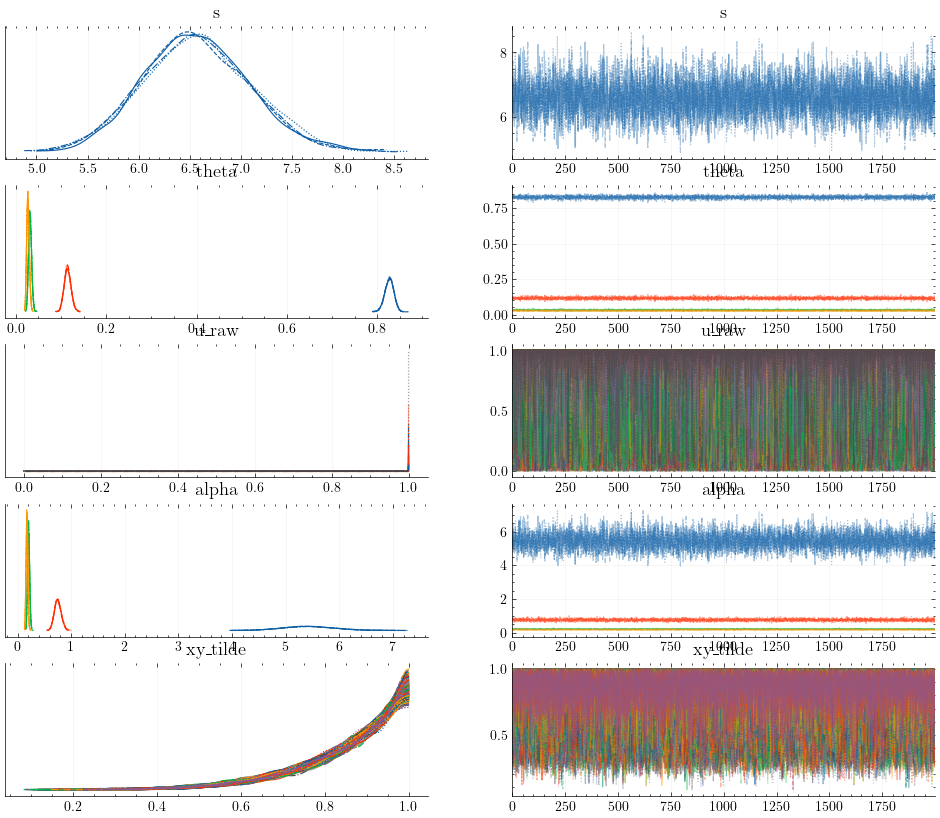

In [60]:
az.plot_trace(idata)
plt.show()

In [61]:
moments = np.zeros((model_fit.alpha.shape[0], 5))
for i in range(model_fit.alpha.shape[0]):
    moments[i,:] = BivariateBeta(model_fit.alpha[i,:]).moments()

In [62]:
moments.mean(axis=0)

array([0.85840901, 0.85374832, 0.01616162, 0.01660337, 0.76202967])

In [63]:
np.median(moments, axis=0)

array([0.85877346, 0.85398404, 0.01606836, 0.01650701, 0.76293013])

In [64]:
from scipy.stats import gaussian_kde

def implied_moments_from_alpha(alpha):
    a1,a2,a3,a4 = alpha[:,0],alpha[:,1],alpha[:,2],alpha[:,3]
    s = a1+a2+a3+a4
    m1 = (a1+a2)/s; m2 = (a1+a3)/s
    v1 = ((a1+a2)*(a3+a4))/(s**2*(s+1))
    v2 = ((a1+a3)*(a2+a4))/(s**2*(s+1))
    rho = (a1*a4 - a2*a3)/np.sqrt((a1+a2)*(a3+a4)*(a1+a3)*(a2+a4))
    return {"m1":m1,"m2":m2,"v1":v1,"v2":v2,"rho":rho}

def observed_moments(x,y):
    m1=x.mean(); m2=y.mean()
    v1=np.mean((x-m1)**2); v2=np.mean((y-m2)**2)
    cov=np.mean((x-m1)*(y-m2)); rho=cov/np.sqrt(v1*v2)
    return {"m1":m1,"m2":m2,"v1":v1,"v2":v2,"rho":rho}

def _overlay_hist_hist_kde(ax, arr_closed, arr_nls, arr_bayes,
                           labels, colors, bins=30,
                           alpha_hist=0.35, lw=1.2):
    """Two stepfilled histograms (MoM-Closed, MoM-NLS) + KDE (Bayes)."""
    arrs = [arr_closed, arr_nls, arr_bayes]
    arrs = [a[np.isfinite(a)] for a in arrs]

    lo = min(a.min() for a in arrs if a.size)
    hi = max(a.max() for a in arrs if a.size)
    span = hi - lo
    pad = 0.05*span if span > 0 else 0.05
    xlo, xhi = lo - pad, hi + pad
    ax.set_xlim(xlo, xhi)

    ax.hist(arrs[0], bins=bins, density=True, histtype='stepfilled',
            color=colors[0], alpha=alpha_hist, edgecolor='black',
            linewidth=lw, label=labels[0])

    ax.hist(arrs[1], bins=bins, density=True, histtype='stepfilled',
            color=colors[1], alpha=alpha_hist, edgecolor='black',
            linewidth=lw, label=labels[1])

    if arrs[2].size:
        kde = gaussian_kde(arrs[2])
        xs = np.linspace(xlo, xhi, 512)
        ys = kde(xs)
        ax.fill_between(xs, 0, ys, color=colors[2], alpha=0.22, label=labels[2])
        ax.plot(xs, ys, color=colors[2], linewidth=1.8)

    ax.grid(True, ls=':', lw=0.6, alpha=0.3)
    ax.set_yticks([])

def plot_moment_distributions(bootstrap_closed, bootstrap_nls, alpha_post,
                                       x_obs, y_obs,
                                       colors=("#0072B2", "#009E73", "#CC79A7")):
    a_closed = np.asarray(bootstrap_closed).T
    a_nls    = np.asarray(bootstrap_nls).T
    a_post   = np.asarray(alpha_post)

    mom_closed = implied_moments_from_alpha(a_closed)
    mom_nls    = implied_moments_from_alpha(a_nls)
    mom_bayes  = implied_moments_from_alpha(a_post)
    obs        = observed_moments(x_obs, y_obs)

    stats  = ["m1","m2","v1","v2","rho"]
    titles = {"m1":r"$m_1$", "m2":r"$m_2$", "v1":r"$v_1$", "v2":r"$v_2$", "rho":r"$\rho$"}
    labels = ["MoM-Closed Bootstrap", "MoM-NLS Bootstrap", "Posterior distribution"]

    fig, axes = plt.subplots(1, 5, figsize=(12, 2.6), constrained_layout=True)
    for ax, k in zip(axes, stats):
        _overlay_hist_hist_kde(ax, mom_closed[k], mom_nls[k], mom_bayes[k],
                               labels, colors)
        ax.axvline(obs[k], color='red', lw=1.1, ls='--')
        ax.set_title(titles[k], fontsize=18)
        ax.tick_params(axis="x", labelsize=14)

    handles, labs = axes[0].get_legend_handles_labels()
    fig.legend(handles, labs, loc='lower center', ncol=3, frameon=False, fontsize=18,
               bbox_to_anchor=(0.5, -0.2))
    plt.savefig('../figures/caseA_ppc_moments.pdf', bbox_inches='tight')
    plt.show()

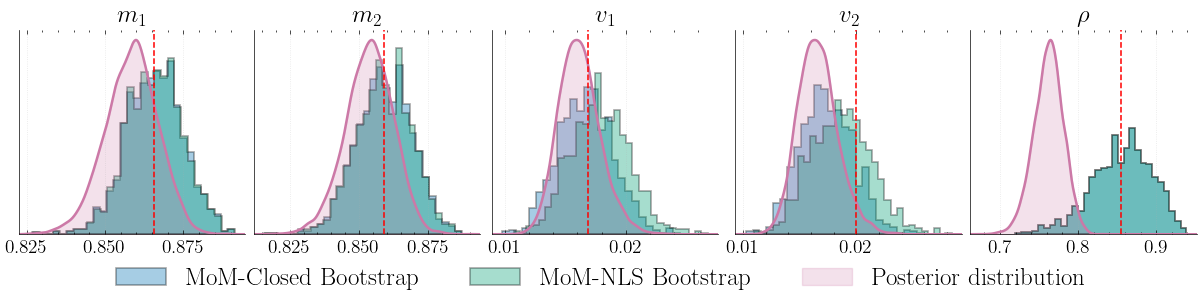

In [65]:
plot_moment_distributions(bootstrap_samples_1, bootstrap_samples_4, model_fit.alpha, x, y)

Fisher interval

In [66]:
import numpy as np

def fisher_z_ci(r, n, conf=0.95):
    r = np.asarray(r, dtype=float)
    if n <= 3:
        raise ValueError("n must be > 3 for Fisher-z interval.")
    # avoid atanh blow-up at boundaries
    r = np.clip(r, -0.999999, 0.999999)

    z = np.arctanh(r)
    se = 1.0 / np.sqrt(n - 3)
    alpha = 1.0 - conf

    try:
        from scipy.stats import norm
        zcrit = norm.ppf(1 - alpha / 2.0)
    except Exception:
        # fallback to standard 95% normal critical value
        zcrit = 1.959963984540054

    z_lo = z - zcrit * se
    z_hi = z + zcrit * se
    return np.tanh(z_lo), np.tanh(z_hi)

# --- Example (your case) ---
r_hat = 0.855
n = 195
lo, hi = fisher_z_ci(r_hat, n, conf=0.95)
print(f"Fisher-z 95% CI for rho: ({lo:.3f}, {hi:.3f})")  # ~ (0.812, 0.889)

Fisher-z 95% CI for rho: (0.812, 0.889)


## Comparing models

In [67]:
B_BOOT = 500

bln_boot_params, bln_boot_indices = bln_bootstrap_mle(model_logit, x, y, B=B_BOOT, seed=2032125)

BLN bootstrap (optimize):   0%|          | 0/500 [00:00<?, ?it/s]

15:57:07 - cmdstanpy - INFO - Chain [1] start processing
15:57:07 - cmdstanpy - INFO - Chain [1] done processing
15:57:07 - cmdstanpy - INFO - Chain [1] start processing
15:57:07 - cmdstanpy - INFO - Chain [1] done processing
15:57:07 - cmdstanpy - INFO - Chain [1] start processing
15:57:07 - cmdstanpy - INFO - Chain [1] done processing
15:57:07 - cmdstanpy - INFO - Chain [1] start processing
15:57:07 - cmdstanpy - INFO - Chain [1] done processing
15:57:07 - cmdstanpy - INFO - Chain [1] start processing
15:57:08 - cmdstanpy - INFO - Chain [1] done processing
15:57:08 - cmdstanpy - INFO - Chain [1] start processing
15:57:08 - cmdstanpy - INFO - Chain [1] done processing
15:57:08 - cmdstanpy - INFO - Chain [1] start processing
15:57:08 - cmdstanpy - INFO - Chain [1] done processing
15:57:08 - cmdstanpy - INFO - Chain [1] start processing
15:57:08 - cmdstanpy - INFO - Chain [1] done processing
15:57:08 - cmdstanpy - INFO - Chain [1] start processing
15:57:08 - cmdstanpy - INFO - Chain [1]

In [68]:
bln_fit = bln_bayes_sample(model_logit, x, y, chains=4, draws=2000, seed=2023215)

bln_idata = az.from_cmdstanpy(
    posterior=bln_fit,
    log_likelihood='log_lik',
    posterior_predictive='xy_tilde',
    coords={'obs_id': np.arange(len(x))},
    dims={'log_lik': ['obs_id'], 'xy_tilde': ['ppc_id', 'dim']},
)

15:57:36 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

15:57:46 - cmdstanpy - INFO - CmdStan done processing.
15:57:46 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: logit_bivariate_model_model_namespace::log_prob: Sigma is not symmetric. Sigma[1,2] = -inf, but Sigma[2,1] = -inf (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/logit-bivariate-model.stan', line 27, column 4 to column 24)If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
	Exception: logit_bivariate_model_model_namespace::log_prob: Sigma is not symmetric. Sigma[1,2] = -inf, but Sigma[2,1] = -inf (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/logit-bivariate-model.stan', line 27, column 4 to column 24)
	Exception: logit_bivariate_model_model_namespace::log_prob: Sigma is not symmetric. Sigma[1,2] = inf, but Sigma[2,1] = inf (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/logit-bivariate-model.stan', line 27, column 4 to column

In [69]:
obs_mom = sample_moments(x, y)
beta_moment_draws, beta_idata = beta_ppc_moments_from_model_fit(model_fit)
beta_loo_cache = build_beta_loglik_cache(x, y, n_quad=48)

loo_res = beta_bayes_loo_from_model_fit(model_fit, cache=beta_loo_cache, take=1000, seed=654322, n_quad=48, batch_size=256)
results = {}
results['beta_bayes'] = {
    'elpd': {
        'elpd_loo': float(loo_res.elpd_loo),
        'se': float(loo_res.se),
        'p_loo': float(loo_res.p_loo),
        'loo_i': loo_res.loo_i.values,
    },
    'moments': {},
}

results['beta_bayes']['moments']['Z'], \
results['beta_bayes']['moments']['mean'], \
results['beta_bayes']['moments']['sd'] = z_scores_from_moment_draws(beta_moment_draws, obs_mom)

# Tail distribution, Brier/Log scores
p_tail_draws = tail_from_posterior_predictive(beta_idata, thr=0.9, take=1000)
results['beta_bayes']['tail'] = {
    'p_mean': float(p_tail_draws.mean()),
    'p_sd':   float(p_tail_draws.std(ddof=1)),
    'p_draws': p_tail_draws,
}

In [70]:
bln_moment_draws = bln_ppc_moments_from_idata(bln_idata)

loo_res = az.loo(bln_idata, pointwise=True)
results['bln_bayes'] = {
    'elpd': {
        'elpd_loo': float(loo_res.elpd_loo),
        'se': float(loo_res.se),
        'p_loo': float(loo_res.p_loo),
        'loo_i': loo_res.loo_i.values,
    },
    'moments': {},
}

results['bln_bayes']['moments']['Z'], \
results['bln_bayes']['moments']['mean'], \
results['bln_bayes']['moments']['sd'] = z_scores_from_moment_draws(bln_moment_draws, obs_mom)

p_tail_draws_bln = tail_from_posterior_predictive(bln_idata, thr=0.9, take=1000)
results['bln_bayes']['tail'] = {
    'p_mean': float(p_tail_draws_bln.mean()),
    'p_sd':   float(p_tail_draws_bln.std(ddof=1)),
    'p_draws': p_tail_draws_bln,
}

In [71]:
mom_list = []
for a in bootstrap_samples_1.T:
    mom_list.append(BivariateBeta(a).moments())
mom_draws = np.asarray(mom_list, dtype=float)

mean_logscore_bibeta, loo_scores_bibeta = loo_logscore_bibeta(x, y, distribution.method_moments_estimator_1, seed=654321, T=20000, nu=1e-8)
results['mom_closed'] = {
    'elpd': {
        'elpd_loo': float(loo_scores_bibeta.sum()),
        'se': elpd_se_from_pointwise(loo_scores_bibeta),
        'p_loo': None,
        'loo_i': loo_scores_bibeta,
    },
    'moments': {},
}

Z, mu_mom, sd_mom = z_scores_from_moment_draws(mom_draws, obs_mom)
results['mom_closed']['moments'] = {'Z': Z, 'mean': mu_mom, 'sd': sd_mom}

p_tail_draws_m1 = tail_from_bibeta_bootstrap(bootstrap_samples_1.T, thr=0.9, T=40000, take=1000)
results['mom_closed']['tail'] = {
    'p_mean': float(p_tail_draws_m1.mean()),
    'p_sd':   float(p_tail_draws_m1.std(ddof=1)),
    'p_draws': p_tail_draws_m1,
}

  0%|          | 0/195 [00:00<?, ?it/s]

Tail from Beta bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

In [72]:
mom_list = []
for a in bootstrap_samples_4.T:
    mom_list.append(BivariateBeta(a).moments())
mom_draws = np.asarray(mom_list, dtype=float)

mean_logscore_bibeta, loo_scores_bibeta = loo_logscore_bibeta(x, y, distribution.method_moments_estimator_4, seed=654321)
results['mom_nls'] = {
    'elpd': {
        'elpd_loo': float(loo_scores_bibeta.sum()),
        'se': elpd_se_from_pointwise(loo_scores_bibeta),
        'p_loo': None,
        'loo_i': loo_scores_bibeta,
    },
    'moments': {},
}

Z, mu_mom, sd_mom = z_scores_from_moment_draws(mom_draws, obs_mom)
results['mom_nls']['moments'] = {'Z': Z, 'mean': mu_mom, 'sd': sd_mom}

p_tail_draws_m4 = tail_from_bibeta_bootstrap(bootstrap_samples_4.T, thr=0.9, T=40000, take=1000)
results['mom_nls']['tail'] = {
    'p_mean': float(p_tail_draws_m4.mean()),
    'p_sd':   float(p_tail_draws_m4.std(ddof=1)),
    'p_draws': p_tail_draws_m4,
}

  0%|          | 0/195 [00:00<?, ?it/s]

Tail from Beta bootstrap:   0%|          | 0/1000 [00:00<?, ?it/s]

In [73]:
mle_list = []
for a in bln_boot_params:
    mle_list.append(bln_moments(mu1=a[0], mu2=a[1], sigma1=a[2], sigma2=a[3], rho=a[4]))
mle_draws = np.asarray(mle_list, dtype=float)

mean_logscore_bln, loo_scores_bln = loo_logscore_bln(x, y, model_logit, seed=654321, B=50)
results['mle'] = {
    'elpd': {
        'elpd_loo': float(loo_scores_bln.sum()),
        'se': elpd_se_from_pointwise(loo_scores_bln),
        'p_loo': None,
        'loo_i': loo_scores_bln,
    },
    'moments': {},
}

Z, mu_mle, sd_mle = z_scores_from_moment_draws(mle_draws, obs_mom)
results['mle']['moments'] = {'Z': Z, 'mean': mu_mle, 'sd': sd_mle}

p_tail_draws = tail_from_bln_bootstrap(bln_boot_params, thr=0.9, T=40000, take=1000)
results['mle']['tail'] = {
    'p_mean': float(p_tail_draws.mean()),
    'p_sd':   float(p_tail_draws.std(ddof=1)),
    'p_draws': p_tail_draws,
}

  0%|          | 0/195 [00:00<?, ?it/s]

15:59:39 - cmdstanpy - INFO - Chain [1] start processing
15:59:39 - cmdstanpy - INFO - Chain [1] done processing
15:59:39 - cmdstanpy - INFO - Chain [1] start processing
15:59:39 - cmdstanpy - INFO - Chain [1] done processing
15:59:39 - cmdstanpy - INFO - Chain [1] start processing
15:59:39 - cmdstanpy - INFO - Chain [1] done processing
15:59:39 - cmdstanpy - INFO - Chain [1] start processing
15:59:39 - cmdstanpy - INFO - Chain [1] done processing
15:59:39 - cmdstanpy - INFO - Chain [1] start processing
15:59:39 - cmdstanpy - INFO - Chain [1] done processing
15:59:39 - cmdstanpy - INFO - Chain [1] start processing
15:59:39 - cmdstanpy - INFO - Chain [1] done processing
15:59:39 - cmdstanpy - INFO - Chain [1] start processing
15:59:39 - cmdstanpy - INFO - Chain [1] done processing
15:59:39 - cmdstanpy - INFO - Chain [1] start processing
15:59:39 - cmdstanpy - INFO - Chain [1] done processing
15:59:39 - cmdstanpy - INFO - Chain [1] start processing
15:59:39 - cmdstanpy - INFO - Chain [1]

Tail from BLN bootstrap:   0%|          | 0/500 [00:00<?, ?it/s]

In [74]:
ind_tail = tail_event_indicators(x, y, thr=0.9).astype(int)

def summarize_brier_log(name, p_draws_or_scalar):
    # use mean p (Bayes) or scalar; Brier/log scores against empirical indicators
    if np.ndim(p_draws_or_scalar) == 0:
        p = float(p_draws_or_scalar)
        b,l = brier_log_scores(ind_tail, p)
        return {'p': p, 'brier': b, 'logscore': l}
    else:
        p_mean = float(np.mean(p_draws_or_scalar))
        b,l = brier_log_scores(ind_tail, p_mean)
        return {'p': p_mean, 'brier': b, 'logscore': l}

summary_rows = []
s = summarize_brier_log('beta_bayes', results['beta_bayes']['tail']['p_draws'])
summary_rows.append(['beta_bayes', s['p'], s['brier'], s['logscore']])

s = summarize_brier_log('bln_bayes', results['bln_bayes']['tail']['p_draws'])
summary_rows.append(['bln_bayes', s['p'], s['brier'], s['logscore']])

s = summarize_brier_log('mom_closed', results['mom_closed']['tail']['p_draws'])
summary_rows.append(['mom_closed', s['p'], s['brier'], s['logscore']])

s = summarize_brier_log('mom_nls', results['mom_nls']['tail']['p_draws'])
summary_rows.append(['mom_nls', s['p'], s['brier'], s['logscore']])

s = summarize_brier_log('mle', results['mle']['tail']['p_draws'])
summary_rows.append(['mle', s['p'], s['brier'], s['logscore']])

summary_df = pd.DataFrame(summary_rows, columns=['model','p_tail','brier','logscore'])
print("Tail-event summary (p_hat, Brier, Log-score):")
display(summary_df)

Tail-event summary (p_hat, Brier, Log-score):


,model,p_tail,brier,logscore
0,beta_bayes,0.388882,0.245822,-0.684861
1,bln_bayes,0.449400,0.245035,-0.683192
2,mom_closed,0.453950,0.245272,-0.683671
3,mom_nls,0.464645,0.245992,-0.685120
4,mle,0.458230,0.245533,-0.684196


In [75]:
elpd_rows = []
elpd_rows.append(['beta_bayes', results['beta_bayes']['elpd']['elpd_loo'], results['beta_bayes']['elpd']['se']])
elpd_rows.append(['bln_bayes', results['bln_bayes']['elpd']['elpd_loo'], results['bln_bayes']['elpd']['se']])
elpd_rows.append(['mom_closed', results['mom_closed']['elpd']['elpd_loo'], results['mom_closed']['elpd']['se']])
elpd_rows.append(['mom_nls', results['mom_nls']['elpd']['elpd_loo'], results['mom_nls']['elpd']['se']])
elpd_rows.append(['mle', results['mle']['elpd']['elpd_loo'], results['mle']['elpd']['se']])
elpd_df = pd.DataFrame(elpd_rows, columns=['model','elpd','elpd_se'])
print("ELPD (Bayes PSIS-LOO and Freq bootstrap-LOO):")
display(elpd_df)

ELPD (Bayes PSIS-LOO and Freq bootstrap-LOO):


,model,elpd,elpd_se
0,beta_bayes,483.990977,34.612547
1,bln_bayes,497.254218,28.837090
2,mom_closed,521.392305,49.758091
3,mom_nls,480.088668,49.356503
4,mle,487.004836,28.837652


In [76]:
def pack_z(model_key, label):
    if model_key not in results: 
        return None
    Z = results[model_key]['moments']['Z']
    mu = results[model_key]['moments']['mean']
    sd = results[model_key]['moments']['sd']
    cols = ['m1','m2','v1','v2','rho']
    row = [label] + list(Z)
    return row, cols

z_rows = []
for key,label in [('beta_bayes','beta_bayes'), ('bln_bayes','bln_bayes'),
                  ('mom_closed','mom_closed'), ('mom_nls','mom_nls'), ('mle', 'mle')]:
    out = pack_z(key, label)
    if out: z_rows.append(out[0]); cols = out[1]
if z_rows:
    z_df = pd.DataFrame(z_rows, columns=['model'] + cols)
    print("Standardized moment misfit Z-scores (observed vs model-implied):")
    display(z_df)

Standardized moment misfit Z-scores (observed vs model-implied):


,model,m1,m2,v1,v2,rho
0,beta_bayes,0.557508,0.392320,0.279359,1.210786,1.604805
1,bln_bayes,0.012559,0.009518,-0.481648,-0.308565,1.502118
2,mom_closed,-0.025921,-0.019465,0.062464,1.080879,-0.015693
3,mom_nls,-0.040942,-0.005914,-0.423506,0.491216,-0.015704
4,mle,0.430075,0.430990,-0.489825,-0.475564,0.408529


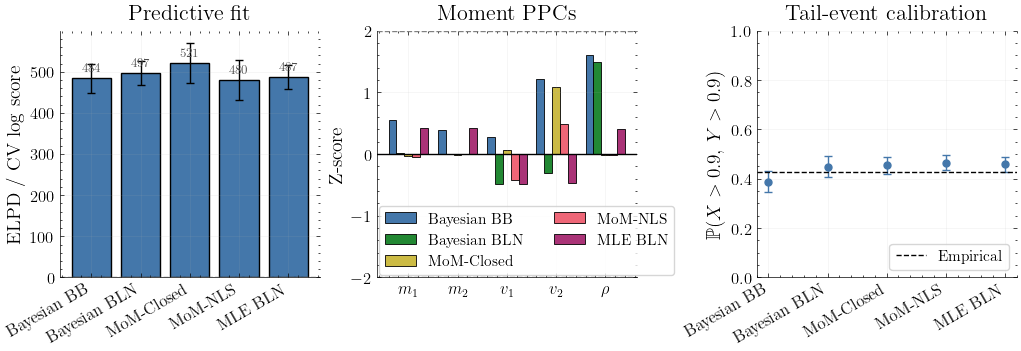

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

# -------------------- styling (paper-friendly) --------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.15,
    "grid.linestyle": "-",
})

# Colorblind-friendly palette (Tol's "bright")
COLORS = ["#4477AA", "#228833", "#CCBB44", "#EE6677", "#AA3377"]

# -------------------- model order & labels --------------------
models = OrderedDict([
    ("beta_bayes", "Bayesian BB"),     # rename here if you prefer another label
    ("bln_bayes",  "Bayesian BLN"),
    ("mom_closed", "MoM-Closed"),
    ("mom_nls",    "MoM-NLS"),
    ("mle",        "MLE BLN"),
])
methods = list(models.values())
xpos = np.arange(len(methods))

# -------------------- pull numbers from your `results` --------------------
elpd_means = [float(results[k]['elpd']['elpd_loo']) for k in models.keys()]
elpd_se    = [float(results[k]['elpd']['se'])       for k in models.keys()]

moment_labels = [r"$m_1$", r"$m_2$", r"$v_1$", r"$v_2$", r"$\rho$"]
moments = { models[k]: np.asarray(results[k]['moments']['Z'], float) for k in models.keys() }

tail_mean = [float(results[k]['tail']['p_mean']) for k in models.keys()]
tail_sd   = [float(results[k]['tail']['p_sd'])   for k in models.keys()]
empirical_tail = float(np.mean((x > 0.9) & (y > 0.9)))

# -------------------- figure --------------------
fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.5), constrained_layout=True)

# ========== Panel 1: Predictive fit ==========
ax = axes[0]
bars = ax.bar(
    xpos, elpd_means, yerr=elpd_se, capsize=3, linewidth=1.0,
    edgecolor="black", color=COLORS[0]
)
ax.axhline(0, color="0.5", linestyle="--", linewidth=1)
ax.set_xticks(xpos)
ax.set_xticklabels(methods, rotation=30, ha="right")
ax.set_ylabel("ELPD / CV log score")
ax.set_title("Predictive fit", pad=8)

# lightly annotate bars (optional; comment out if you prefer clean bars)
for rect in bars:
    ax.annotate(f"{rect.get_height():.0f}",
                xy=(rect.get_x() + rect.get_width()/2, rect.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=9, color="0.3")

# ========== Panel 2: Moment PPC Z-scores ==========
ax = axes[1]
width = 0.16
for j, method in enumerate(methods):
    zvals = moments[method]
    ax.bar(np.arange(len(moment_labels)) + j*width, zvals,
           width=width, label=method, color=COLORS[j], edgecolor="black", linewidth=0.6)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(2, color="0.5", linestyle="--", linewidth=1)
ax.axhline(-2, color="0.5", linestyle="--", linewidth=1)
ax.set_xticks(np.arange(len(moment_labels)) + 2*width)
ax.set_xticklabels(moment_labels)
ax.set_ylabel("Z-score")
ax.set_title("Moment PPCs", pad=8)
ax.legend(ncol=2, frameon=True, loc="lower left", bbox_to_anchor=(-0.02, -0.02))

# Set a reasonable y-range if extreme MoM Z's appear
z_all = np.concatenate([moments[m] for m in methods])
z_lim = np.percentile(np.abs(z_all), 98)  # robust
ax.set_ylim(-max(2, z_lim), max(2, z_lim))

# ========== Panel 3: Tail-event calibration ==========
ax = axes[2]
ax.errorbar(xpos, tail_mean, yerr=tail_sd, fmt="o", ms=5,
            elinewidth=1.0, capsize=3, color=COLORS[0])
ax.axhline(empirical_tail, color="black", linestyle="--", linewidth=1, label="Empirical")
ax.set_xticks(xpos)
ax.set_xticklabels(methods, rotation=30, ha="right")
ax.set_ylabel(r"$\mathbb{P}(X > 0.9,\, Y > 0.9)$")
# auto y-limits with a little padding
lo = min(min(tail_mean) - 2*max(tail_sd), 0.0)
hi = max(max(tail_mean) + 2*max(tail_sd), 1.0)
ax.set_ylim(max(0.0, lo), min(1.0, hi))
ax.set_title("Tail-event calibration", pad=8)
ax.legend(frameon=True, loc="lower right")

# -------------------- save (vector + raster) --------------------
plt.savefig("../figures/caseA_comparison.pdf", bbox_inches="tight")
plt.show()

### Visual diagnostics for the OT fit versus the logit-normal

This figure repeats the same posterior-predictive comparison for Case A, using full-support joint contours and marginal Q-Q-style diagnostics for the two coverage margins.

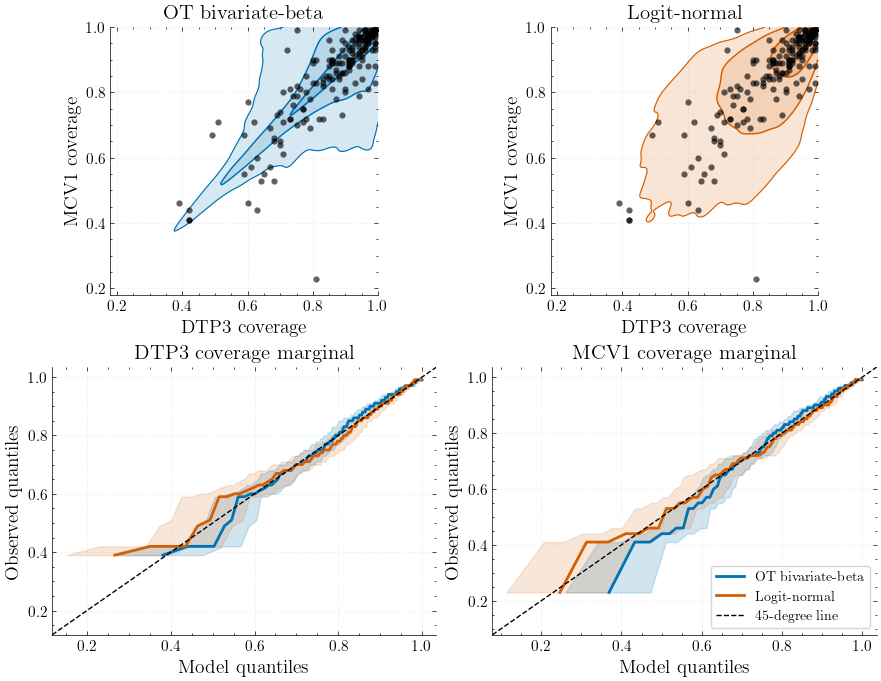

In [84]:
plot_ot_vs_bln_visual_diagnostics(
    x=x,
    y=y,
    beta_idata=beta_idata,
    bln_idata=bln_idata,
    case_label='Case A: share of immunized children',
    xlabel='DTP3 coverage',
    ylabel='MCV1 coverage',
    figure_path='../figures/caseA_visual_diagnostics.pdf',
)

<!-- PRIOR_SENSITIVITY_CASE_A -->
## Prior sensitivity analysis

This block reruns the Bayesian OT bivariate-beta fit for Case A under the full 8-prior matrix and saves reviewer-facing outputs to `../experiments/sensitivity/caseA_prior_sensitivity_*.csv`.


In [79]:
# PRIOR_SENSITIVITY_CASE_A
caseA_prior_sensitivity = run_prior_sensitivity_case(
    case_id='caseA',
    case_label='Case A: share of immunized children',
    x=x,
    y=y,
    include_pr_rho_negative=False,
    tail_threshold=0.9,
    seed_base=202603400,
)

print(f"Saved summary to {caseA_prior_sensitivity['summary_path']}")
print(f"Saved implied moments to {caseA_prior_sensitivity['moments_path']}")
display(caseA_prior_sensitivity['summary'].round(4))
display(caseA_prior_sensitivity['moments'].round(4))


16:11:44 - cmdstanpy - INFO - CmdStan start processing


[caseA] Running P_0 (Baseline)


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 4 |          | 00:00 Status

16:19:52 - cmdstanpy - INFO - CmdStan done processing.
16:19:52 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Random variable is 0, but must be positive finite! (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/bivariate-beta-model-gamma.stan', line 56, column 3 to column 28)
	Exception: gamma_lpdf: Random variable is 0, but must be positive finite! (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/bivariate-beta-model-gamma.stan', line 56, column 3 to column 28)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/bivariate-beta-model-gamma.stan', line 56, column 3 to column 28)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in '/Users/lmm122/Documents/github/bivariate-beta/scripts/stan/bivariate-beta-model-gamma.stan', line 56, column 3 to column 28)
	Exception: gamma_lpdf: Random variable is 0, but must b


Saved summary to ../experiments/sensitivity/caseA_prior_sensitivity_summary.csv
Saved implied moments to ../experiments/sensitivity/caseA_prior_sensitivity_moments.csv


,prior_id,label,theta_prior,s_prior,justification,status,rho_median,rho_ci_low,rho_ci_high,elpd_loo,...,tail_prob_sd,empirical_tail_prob,pr_rho_lt_0,divergences,max_rhat,min_bulk_ess,min_tail_ess,bfmi_min,bfmi_mean,delta_elpd_vs_p0
0,P_0,Baseline,"Dir(1, 1, 1, 1)","LN(log 4, 1)","Weakly informative, flat baseline.",ok,0.7630,0.7267,0.8002,483.8888,...,0.0428,0.4256,NaN,0,1.0,4412.0,5865.0,0.7021,0.7228,0.0000
1,P_1,Gamma,"Dir(1, 1, 1, 1)","Gamma(4, 1)",Shape sensitivity.,ok,0.7616,0.7248,0.7980,484.1168,...,0.0435,0.4256,NaN,0,1.0,4164.0,5863.0,0.6840,0.7006,0.2280
2,P_2,Vague,"Dir(0.5, 0.5, 0.5, 0.5)","LN(log 4, 2)","Jeffreys-like, very broad.",ok,0.7644,0.7260,0.8009,483.9393,...,0.0415,0.4256,NaN,0,1.0,3827.0,5506.0,0.6326,0.7195,0.0505
3,P_3,Sparse,"Dir(0.1, 0.1, 0.1, 0.1)","LN(log 4, 1)",Favors extreme or polarized values.,ok,0.7645,0.7276,0.8000,483.4474,...,0.0434,0.4256,NaN,0,1.0,4243.0,5570.0,0.6630,0.6869,-0.4414
4,P_4,Indep.,"Dir(10, 10, 10, 10)","LN(log 4, 1)",Bias toward zero correlation.,ok,0.7421,0.7010,0.7774,487.5337,...,0.0436,0.4256,NaN,0,1.0,3269.0,4715.0,0.6350,0.6683,3.6449
5,P_5,Adversarial,"Dir(1, 2, 2, 1)","LN(log 4, 1)",Bias toward negative correlation.,ok,0.7600,0.7238,0.7979,484.5885,...,0.0433,0.4256,NaN,0,1.0,4515.0,5675.0,0.6837,0.7095,0.6998
6,P_6,Strong s,"Dir(1, 1, 1, 1)","LN(log 4, 0.2)",Low variance on concentration.,ok,0.7557,0.7171,0.7910,481.9255,...,0.0413,0.4256,NaN,0,1.0,3807.0,5056.0,0.6771,0.7211,-1.9632
7,P_7,Asym-Vague,"Dir(1, 2, 0.5, 1)","Gamma(2, 0.5)",Asymmetric and highly broad.,ok,0.7619,0.7244,0.7983,483.7488,...,0.0420,0.4256,NaN,0,1.0,3448.0,5180.0,0.6380,0.6700,-0.1399


,prior_id,label,posterior_mean_m1,posterior_mean_v1,posterior_mean_m2,posterior_mean_v2,posterior_mean_rho,posterior_median_m1,posterior_median_v1,posterior_median_m2,posterior_median_v2,posterior_median_rho
0,P_0,Baseline,0.8584,0.0162,0.8538,0.0166,0.7622,0.8586,0.0161,0.8541,0.0165,0.7630
1,P_1,Gamma,0.8577,0.0164,0.8530,0.0169,0.7608,0.8581,0.0163,0.8534,0.0168,0.7616
2,P_2,Vague,0.8591,0.0160,0.8545,0.0164,0.7637,0.8594,0.0159,0.8549,0.0163,0.7644
3,P_3,Sparse,0.8595,0.0159,0.8549,0.0163,0.7641,0.8598,0.0158,0.8551,0.0162,0.7645
4,P_4,Indep.,0.8474,0.0189,0.8424,0.0194,0.7412,0.8475,0.0188,0.8427,0.0193,0.7421
5,P_5,Adversarial,0.8578,0.0164,0.8532,0.0168,0.7593,0.8580,0.0162,0.8533,0.0167,0.7600
6,P_6,Strong s,0.8544,0.0176,0.8496,0.0181,0.7550,0.8547,0.0175,0.8499,0.0179,0.7557
7,P_7,Asym-Vague,0.8582,0.0163,0.8531,0.0168,0.7612,0.8585,0.0162,0.8535,0.0167,0.7619


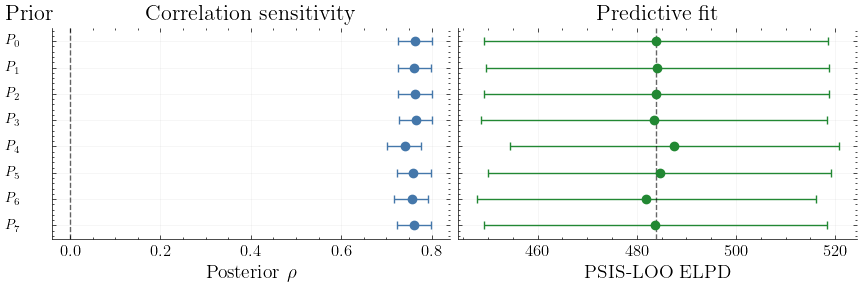

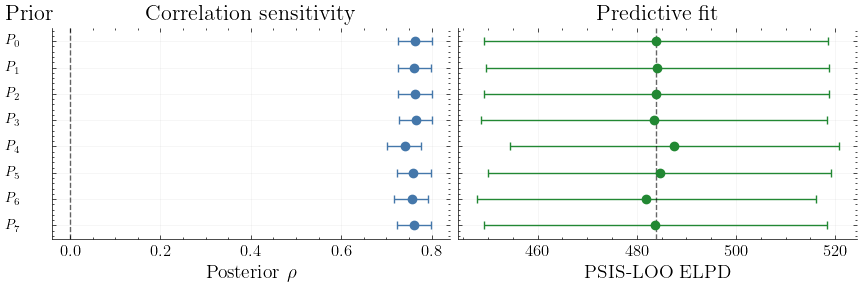

In [80]:
plot_prior_sensitivity_overview(
    caseA_prior_sensitivity['summary'],
    case_label=caseA_prior_sensitivity['case_label'],
    figure_path=Path('../figures/caseA_prior_sensitivity.pdf'),
)